In [411]:
import sys
sys.path.append('../')
import scipy.io as sio
import mat73
import pandas as pd
import torch
import numpy as np
import torch.optim as optim
import torch.nn
import sklearn
import sklearn.metrics
import matplotlib.pyplot as plt
from alive_progress import alive_bar
from  utils.my_classes import dataset 
from torch.utils.data import DataLoader
import utils.DNN_functions as DNN_functions
import scipy
import random
import utils.AMSloss
from speechbrain.pretrained import SpeakerRecognition
import pickle
import os
from utils.my_classes import dataset
import utils.eval_metrics as eval_metrics
import copy
from speechbrain.pretrained import SpeakerRecognition
from a_DCF.a_DCF_package.a_dcf import a_dcf

seed = 42  # You can choose any integer value as the seed
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
# Set seed for Python's random module
random.seed(seed)
# Set seed for NumPy
np.random.seed(seed)
# Set seed for PyTorch (CPU and GPU, if available)
if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
# Set deterministic flags for PyTorch (if available)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [412]:
#To get my GPU device - GTX 4070 :)
seed = 42  # You can choose any integer value as the seed
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');

if torch.cuda.is_available():
    print(torch.cuda.device_count())
    print(torch.cuda.device(0))
    print(torch.cuda.get_device_name(0))
    print(device)

1
NVIDIA GeForce RTX 4070
cuda


# loading the embedding for CM System:

In [413]:
from ASV_utils.data_loading import *



models_folder = "ECAPA_TDNN/inference_models/models_both_not_normalize/"

data_path_male = "Data/pmf_both/not_normalize/male/"

data_path_female = "Data/pmf_both/not_normalize/female/"

male_embedded_groups_1_1,male_embedded_groups_1_2,male_embedded_groups_1_3,male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id,male_chosen_labels_3_1_speaker_id,male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex  = load_data_male(data_path_male)

female_embedded_groups_1_1,female_embedded_groups_1_2,female_embedded_groups_1_3,female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex  = load_data_female(data_path_female)

# Pre Processing the channels And loading the Models - Male & Female:

In [414]:

import utils.my_functions as my_functions

columns_names,max_name_length = my_functions.get_columns_names_feature_importance(substruct=True)
true_channels_indexes = np.array(my_functions.get_real_channel(np.linspace(start=1, stop=len(columns_names), num=len(columns_names)),len(columns_names)))
true_channels_indexes = true_channels_indexes - 1
true_channels_indexes = true_channels_indexes.astype(int)
columns_names = np.array(columns_names)

female_embedded_groups_1_1 = female_embedded_groups_1_1[:,true_channels_indexes]
female_embedded_groups_1_2 = female_embedded_groups_1_2[:,true_channels_indexes]
female_embedded_groups_1_3 = female_embedded_groups_1_3[:,true_channels_indexes]

male_embedded_groups_1_1 = male_embedded_groups_1_1[:,true_channels_indexes]
male_embedded_groups_1_2 = male_embedded_groups_1_2[:,true_channels_indexes]
male_embedded_groups_1_3 = male_embedded_groups_1_3[:,true_channels_indexes]

In [415]:
from sklearn.preprocessing import StandardScaler
import re

your_list = columns_names[true_channels_indexes]
index_mapping ={}

# Define the custom sorting order for distance metrics
distance_metrics = [
    'Chi-square',
    'Correlation',
    'Hellinger',
    'Intersection',
    'Jensen-Shannon',
    'Kullback-Leibler Divergence',
    'Modified Kolmogorov-Smirnov',
    'Symmetrised Kullback-Leibler'
]

def custom_sort_key(item):
    # Use regex to extract gammatone, gammatone_inv, channel number, and distance metric
    match = re.search(r'filter-(gammatone(?:_inv)?)-channel-(\d+)-distance-(.+?)-\[d_', item)
    if match:
        gammatone = match.group(1)
        channel = int(match.group(2))
        distance_metric = match.group(3)

        # Assign a higher priority to distance_order, a medium priority to channels,
        # and lower priority to 'gammatone' and 'gammatone_inv'
        return (distance_metrics.index(distance_metric), channel, gammatone)

    else:
        # If the regex doesn't match, return the original item to maintain its position
        return (999, 999, "")

# Sort the list based on the custom order
sorted_list = sorted(your_list, key=custom_sort_key)

for new_index, item in enumerate(sorted_list):
    old_index = np.where(columns_names[true_channels_indexes] == item)[0][0]
    index_mapping[old_index] = new_index
    
male_embedded_groups_1_1 = male_embedded_groups_1_1[:,list(index_mapping.keys())]
male_embedded_groups_1_2 = male_embedded_groups_1_2[:,list(index_mapping.keys())]
male_embedded_groups_1_3 = male_embedded_groups_1_3[:,list(index_mapping.keys())]

female_embedded_groups_1_1 = female_embedded_groups_1_1[:,list(index_mapping.keys())]
female_embedded_groups_1_2 = female_embedded_groups_1_2[:,list(index_mapping.keys())]
female_embedded_groups_1_3 = female_embedded_groups_1_3[:,list(index_mapping.keys())]



In [416]:
# define the subchannel model network
import torch
import torch.nn as nn
from utils.AMSloss import AdMSoftmaxLoss
import pickle
# define the subchannel model network
import torch.nn as nn
class SubChannelNetwork(nn.Module):
    def __init__(self, input_channel_size, output_channel_size):
        super(SubChannelNetwork, self).__init__()
        self.input_layer = nn.Linear(input_channel_size, output_channel_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)
        self.BN_4 = nn.BatchNorm1d(output_channel_size) 

        
    def forward(self, x):
        x = self.input_layer(x)
        x = self.BN_4(x) 
        x = self.sigmoid(x)
        x = self.dropout(x)
        return x

# define the model network
class DNN(nn.Module):
    def __init__(self, input_channel_size, num_subnetworks, output_channel_size, final_output_size):
        super(DNN, self).__init__()
        self.SubChannelNetwork = nn.ModuleList([
            SubChannelNetwork(input_channel_size, output_channel_size) for _ in range(num_subnetworks)
        ])
        self.fc_between_subnet = nn.Linear(num_subnetworks * output_channel_size,40)
        self.BN = nn.BatchNorm1d(40)
        self.fc = nn.Linear(40, final_output_size)
        self.sigmoid = nn.Sigmoid()
        self.droupout = nn.Dropout(p=0.2)
        self.loss = nn.BCEWithLogitsLoss()
        self.optimizer = None
        self.scheduler = None
        
        
    def forward(self, x):
        subnetwork_outputs = [self.SubChannelNetwork[idx](x[:, idx*input_channel_size:(idx+1)*input_channel_size].to(device)) for idx in range(len(self.SubChannelNetwork))]
        combined_output = torch.cat(subnetwork_outputs, dim=1)
        x = self.fc_between_subnet(combined_output)    
        x = self.BN(x)
        x = self.sigmoid(x)
        x = self.droupout(x)
        output = self.fc(x)
        return output 
    
    @staticmethod
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)



# Just for checking the model and see the number of parameters
num_SubChannelNetwork = 16
input_channel_size = 10
output_channel_size = 5
final_output_size = 1
model = []
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size)
model = model.to(device)
print(model)
n = DNN.count_parameters(model)
print("Number of parameters: %s" % n)
model = model.to(device) # send the model to the device

model = pickle.load(open(models_folder + "CM_both_male_9_2.pkl", 'rb'))

model.eval()

spoof_model_male = copy.deepcopy(model)

DNN(
  (SubChannelNetwork): ModuleList(
    (0-15): 16 x SubChannelNetwork(
      (input_layer): Linear(in_features=10, out_features=5, bias=True)
      (sigmoid): Sigmoid()
      (dropout): Dropout(p=0.2, inplace=False)
      (BN_4): BatchNorm1d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (fc_between_subnet): Linear(in_features=80, out_features=40, bias=True)
  (BN): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=40, out_features=1, bias=True)
  (sigmoid): Sigmoid()
  (droupout): Dropout(p=0.2, inplace=False)
  (loss): BCEWithLogitsLoss()
)
Number of parameters: 4401


In [417]:
import torch
import torch.nn as nn
from utils.AMSloss import AdMSoftmaxLoss
from utils.OCSoftmaxloss import OCSoftmax
import torch.nn as nn

class SubChannelNetwork(nn.Module):
    def __init__(self, input_channel_size, output_channel_size):
        super(SubChannelNetwork, self).__init__()
        self.input_layer = nn.Linear(input_channel_size, output_channel_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)
        self.BN_4 = nn.BatchNorm1d(output_channel_size) 
   
    def forward(self, x):
        res = x
        x = self.input_layer(x)
        x = self.BN_4(x) 
        x = self.sigmoid(x)
        x = self.dropout(x)
        x = res + x 
        return x

class DNN(nn.Module):
    def __init__(self, input_channel_size, num_subnetworks, output_channel_size, final_output_size, r_real , r_fake,alpha):
        super(DNN, self).__init__()
        self.SubChannelNetwork = nn.ModuleList([
            SubChannelNetwork(input_channel_size, output_channel_size) for _ in range(num_subnetworks)
        ])
        self.fc_between_subnet = nn.Linear(num_subnetworks * output_channel_size,40)
        self.BN = nn.BatchNorm1d(40)
        self.fc = nn.Linear(40, final_output_size)
        self.sigmoid = nn.Sigmoid()
        self.droupout = nn.Dropout(p=0.2)
        self.r_real = r_real
        self.r_fake = r_fake
        self.alpha = alpha
        self.loss = OCSoftmax(feat_dim = final_output_size, r_real = self.r_real, r_fake = self.r_fake, alpha = self.alpha)
        self.optimizer = None
        self.scheduler = None
        
        
    def forward(self, x):
        subnetwork_outputs = [self.SubChannelNetwork[idx](x[:, idx*input_channel_size:(idx+1)*input_channel_size].to(device)) for idx in range(len(self.SubChannelNetwork))]
        combined_output = torch.cat(subnetwork_outputs, dim=1)
        x = self.fc_between_subnet(combined_output)    
        x = self.BN(x)
        x = self.sigmoid(x)
        x = self.droupout(x)
        output = self.fc(x)
        return output 
    
    @staticmethod
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)

r_real = 0.5 
r_fake = 0.1
alpha = 20
# Example usage
num_SubChannelNetwork = 16
input_channel_size = 10
output_channel_size = 10
final_output_size = 16*3
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size,r_real = r_real , r_fake = r_fake,alpha = alpha)


model = model.to(device) # send the model to the device

model = pickle.load(open(models_folder + "CM_both_female_10_17.pkl", 'rb'))

model.eval()

spoof_model_female = copy.deepcopy(model)


In [418]:
scaler_male = StandardScaler(with_mean = True, with_std = True)
scaler_male.fit(male_embedded_groups_1_1)
mean_features = scaler_male.mean_
std_features = scaler_male.scale_
male_embedded_groups_1_1_norm = scaler_male.transform(male_embedded_groups_1_1)
male_embedded_groups_1_2_norm = scaler_male.transform(male_embedded_groups_1_2)
male_embedded_groups_1_3_norm = scaler_male.transform(male_embedded_groups_1_3)


scaler_female = StandardScaler(with_mean = True, with_std = True)
scaler_female.fit(female_embedded_groups_1_1)
mean_features = scaler_female.mean_
std_features = scaler_female.scale_
female_embedded_groups_1_1_norm = scaler_female.transform(female_embedded_groups_1_1)
female_embedded_groups_1_2_norm = scaler_female.transform(female_embedded_groups_1_2)
female_embedded_groups_1_3_norm = scaler_female.transform(female_embedded_groups_1_3)

In [419]:
embedded_groups_1_1_norm,embedded_groups_1_2_norm,embedded_groups_1_3_norm,chosen_labels_1_1_is_spoofed,chosen_labels_2_1_is_spoofed,chosen_labels_3_1_is_spoofed,chosen_labels_numeric_1_1,chosen_labels_numeric_2_1,chosen_labels_numeric_3_1,chosen_labels_1_1_attack_logical,chosen_labels_2_1_attack_logical,chosen_labels_3_1_attack_logical,chosen_labels_1_1_name,chosen_labels_2_1_name,chosen_labels_3_1_name,chosen_labels_1_1_speaker_id,chosen_labels_2_1_speaker_id,chosen_labels_3_1_speaker_id,chosen_labels_1_1_sex,chosen_labels_2_1_sex,chosen_labels_3_1_sex    =  concatenate_data(male_embedded_groups_1_1_norm,male_embedded_groups_1_2_norm,male_embedded_groups_1_3_norm,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id, male_chosen_labels_3_1_speaker_id,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_embedded_groups_1_1_norm,female_embedded_groups_1_2_norm,female_embedded_groups_1_3_norm,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex)


In [420]:
embedded_groups_1_1,embedded_groups_1_2,embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_    =  concatenate_data(male_embedded_groups_1_1,male_embedded_groups_1_2,male_embedded_groups_1_3,
                                                                                                                        male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,
                                                                                                                        male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,
                                                                                                                        male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,
                                                                                                                        male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,
                                                                                                                        male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id, male_chosen_labels_3_1_speaker_id,
                                                                                                                        male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex,
                                                                                                                        
                                                                                                                        female_embedded_groups_1_1,female_embedded_groups_1_2,female_embedded_groups_1_3,
                                                                                                                        female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,
                                                                                                                        female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,
                                                                                                                        female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,
                                                                                                                        female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,
                                                                                                                        female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,
                                                                                                                        female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex)
scaler_all = StandardScaler(with_mean = True, with_std = True)
scaler_all.fit(embedded_groups_1_1)
mean_features = scaler_female.mean_
std_features = scaler_female.scale_
embedded_groups_1_1_all = scaler_all.transform(embedded_groups_1_1)
embedded_groups_1_2_all = scaler_all.transform(embedded_groups_1_2)
embedded_groups_1_3_all = scaler_all.transform(embedded_groups_1_3)

In [421]:
train_dataset_all = dataset(data = embedded_groups_1_1_norm , is_spoofed = chosen_labels_1_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_1_1,
                        attack_logical = chosen_labels_1_1_attack_logical, name = chosen_labels_1_1_name , speaker_id = chosen_labels_1_1_speaker_id, sex = chosen_labels_1_1_sex ,data_transform = None , labels_transform = None,
                        data_for_gender_classification = None,data_without_separation = embedded_groups_1_1_all);

Dev_dataset_all = dataset(data = embedded_groups_1_2_norm , is_spoofed = chosen_labels_2_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_2_1,
                        attack_logical = chosen_labels_2_1_attack_logical, name = chosen_labels_2_1_name , speaker_id = chosen_labels_2_1_speaker_id, sex = chosen_labels_2_1_sex ,  data_transform = None , labels_transform = None,
                        data_for_gender_classification = None,data_without_separation = embedded_groups_1_2_all);


Eval_dataset_all = dataset(data = embedded_groups_1_3_norm , is_spoofed = chosen_labels_3_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_3_1,
                        attack_logical = chosen_labels_3_1_attack_logical, name = chosen_labels_3_1_name , speaker_id = chosen_labels_3_1_speaker_id, sex = chosen_labels_3_1_sex , data_transform = None , labels_transform = None,
                        data_for_gender_classification = None,data_without_separation = embedded_groups_1_3_all);


In [422]:
train_dataset_all.name = np.array([str(elem).split("/")[-1].split("'")[0].split('.flac')[0] for elem in train_dataset_all.name])

Dev_dataset_all.name = np.array([str(elem).split("/")[-1].split("'")[0].split('.flac')[0] for elem in Dev_dataset_all.name])

Eval_dataset_all.name = np.array([str(elem).split("/")[-1].split("'")[0].split('.flac')[0] for elem in Eval_dataset_all.name])

In [423]:
from ASV_utils.data_loading import *


models_folder = "ECAPA_TDNN/inference_models/models_both_not_normalize/"

data_path_male = "Data/male_vs_female_DB_models/16_bits/none/male/"

data_path_female = "Data/male_vs_female_DB_models/16_bits/none/female/"

g_male_embedded_groups_1_1,g_male_embedded_groups_1_2,g_male_embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_  = load_data_male(data_path_male)

g_female_embedded_groups_1_1,g_female_embedded_groups_1_2,g_female_embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_  = load_data_female(data_path_female)

embedded_groups_1_1,embedded_groups_1_2,embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_    =  concatenate_data(g_male_embedded_groups_1_1,g_male_embedded_groups_1_2,g_male_embedded_groups_1_3,
                                                                                                                    male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,
                                                                                                                    male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,
                                                                                                                    male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,
                                                                                                                    male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,
                                                                                                                    male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id, male_chosen_labels_3_1_speaker_id,
                                                                                                                    male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex,
                                                                                                                    
                                                                                                                    g_female_embedded_groups_1_1,g_female_embedded_groups_1_2,g_female_embedded_groups_1_3,
                                                                                                                    female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,
                                                                                                                    female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,
                                                                                                                    female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,
                                                                                                                    female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,
                                                                                                                    female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,
                                                                                                                    female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex)
chosen_labels_1_1_sex = np.array([elem[0] for elem in chosen_labels_1_1_sex])
                                 
chosen_labels_2_1_sex = np.array([elem[0] for elem in chosen_labels_2_1_sex])

chosen_labels_3_1_sex = np.array([elem[0] for elem in chosen_labels_3_1_sex])


In [424]:



import utils.my_functions as my_functions

columns_names,max_name_length = my_functions.get_columns_names_feature_importance(substruct=True)
true_channels_indexes = np.array(my_functions.get_real_channel(np.linspace(start=1, stop=len(columns_names), num=len(columns_names)),len(columns_names)))
true_channels_indexes = true_channels_indexes - 1
true_channels_indexes = true_channels_indexes.astype(int)
columns_names = np.array(columns_names)
'''
g_female_embedded_groups_1_1 = g_female_embedded_groups_1_1[:,true_channels_indexes]
g_female_embedded_groups_1_2 = g_female_embedded_groups_1_2[:,true_channels_indexes]
g_female_embedded_groups_1_3 = g_female_embedded_groups_1_3[:,true_channels_indexes]

g_male_embedded_groups_1_1 = g_male_embedded_groups_1_1[:,true_channels_indexes]
g_male_embedded_groups_1_2 = g_male_embedded_groups_1_2[:,true_channels_indexes]
g_male_embedded_groups_1_3 = g_male_embedded_groups_1_3[:,true_channels_indexes]
'''

embedded_groups_1_1 = embedded_groups_1_1[:,true_channels_indexes]
embedded_groups_1_2 = embedded_groups_1_2[:,true_channels_indexes]
embedded_groups_1_3 = embedded_groups_1_3[:,true_channels_indexes]

from sklearn.preprocessing import StandardScaler
import re

your_list = columns_names[true_channels_indexes]
index_mapping ={}

# Define the custom sorting order for distance metrics
distance_metrics = [
    'Chi-square',
    'Correlation',
    'Hellinger',
    'Intersection',
    'Jensen-Shannon',
    'Kullback-Leibler Divergence',
    'Modified Kolmogorov-Smirnov',
    'Symmetrised Kullback-Leibler'
]

def custom_sort_key(item):
    # Use regex to extract gammatone, gammatone_inv, channel number, and distance metric
    match = re.search(r'filter-(gammatone(?:_inv)?)-channel-(\d+)-distance-(.+?)-\[d_', item)
    if match:
        gammatone = match.group(1)
        channel = int(match.group(2))
        distance_metric = match.group(3)

        # Assign a higher priority to distance_order, a medium priority to channels,
        # and lower priority to 'gammatone' and 'gammatone_inv'
        return (distance_metrics.index(distance_metric), channel, gammatone)

    else:
        # If the regex doesn't match, return the original item to maintain its position
        return (999, 999, "")

# Sort the list based on the custom order
sorted_list = sorted(your_list, key=custom_sort_key)

for new_index, item in enumerate(sorted_list):
    old_index = np.where(columns_names[true_channels_indexes] == item)[0][0]
    index_mapping[old_index] = new_index
    

embedded_groups_1_1 = embedded_groups_1_1[:,list(index_mapping.keys())]
embedded_groups_1_2 = embedded_groups_1_2[:,list(index_mapping.keys())]
embedded_groups_1_3 = embedded_groups_1_3[:,list(index_mapping.keys())]




In [425]:
scaler = StandardScaler(with_mean = True, with_std = True)
scaler.fit(embedded_groups_1_1)
mean_features = scaler.mean_
std_features = scaler.scale_

embedded_groups_1_1 = scaler.transform(embedded_groups_1_1)
embedded_groups_1_2 = scaler.transform(embedded_groups_1_2)
embedded_groups_1_3 = scaler.transform(embedded_groups_1_3)

train_dataset_all.data_for_gender_classification = embedded_groups_1_1
Dev_dataset_all.data_for_gender_classification   = embedded_groups_1_2
Eval_dataset_all.data_for_gender_classification  = embedded_groups_1_3


train_dataset_all.sex = pd.Series([elem[0] for elem in train_dataset_all.sex])
Dev_dataset_all.sex = pd.Series([elem[0] for elem in Dev_dataset_all.sex])
Eval_dataset_all.sex = pd.Series([elem[0] for elem in Eval_dataset_all.sex])

In [426]:
total_labels = torch.Tensor(Eval_dataset_all.is_spoofed[(Eval_dataset_all.sex == 'female').values].values).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data[(Eval_dataset_all.sex == 'female').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    test_output = spoof_model_female(torch.Tensor(total_data).to(device))
    loss , test_score = spoof_model_female.loss(torch.Tensor(test_output).to(device),None)
    test_score = -1*test_score
    
test_score_total = test_score.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels,test_score_total) # compute equal error rate

print(f"\tTest EER: ({eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (0.10177271288382395%) 	Test Threshold: -0.8237718060240031


In [427]:
total_labels = torch.Tensor(Eval_dataset_all.is_spoofed[(Eval_dataset_all.sex == 'male').values].values).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data[(Eval_dataset_all.sex == 'male').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    test_score = torch.sigmoid(spoof_model_male(torch.Tensor(total_data).to(device)))
    
test_score_total = test_score.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels,test_score_total) # compute equal error rate

print(f"\tTest EER: ({eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (0.09203296703296708%) 	Test Threshold: 0.04938841153161375


In [428]:
import torchaudio
from speechbrain.pretrained import EncoderClassifier

# load the model - the moodel that check if it's female or male
with open(os.path.join(models_folder,"gender_XGB_model_both_norm_male_vs_female_db_models.pkl"), 'rb') as fp:
#with open(os.path.join(models_folder,"gender_XGB_model_both_norm_male_vs_female_db_models.pkl"), 'rb') as fp:
    gender_model = pickle.load(fp)
    
# load the model - the model that check if it's the sampe speaker or not
verification_model = SpeakerRecognition.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir='./ECAPA_TDNN/pretrained_models/spkrec-ecapa-voxceleb',run_opts={"device":"cuda"} )

classifier = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir='./ECAPA_TDNN/pretrained_models/spkrec-ecapa-voxceleb',run_opts={"device":"cuda"})



In [429]:
import pickle
from ASV_utils.ASV_my_functions import *
# Load the embeddings file:

with open('./ECAPA_TDNN/embeddings/dev_embedding_ecapa_voxceleb_flac.pkl', 'rb') as file:
    list_dev_files,embeddings_dev = pickle.load(file)
    list_dev_files = [name.rstrip('.flac') for name in list_dev_files]
    
with open('./ECAPA_TDNN/embeddings/eval_embedding_ecapa_voxceleb_flac.pkl', 'rb') as file:
    list_eval_files,embeddings_eval = pickle.load(file)
    list_eval_files = [name.rstrip('.flac') for name in list_eval_files]


embeddings_dev =[emb.cpu() for emb in embeddings_dev]
embeddings_dev = np.concatenate(embeddings_dev, axis=0)
embeddings_eval =[emb.cpu() for emb in embeddings_eval]
embeddings_eval = np.concatenate(embeddings_eval, axis=0)


path_enrollment_dev_female = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.female.trn.txt"

path_enrollment_dev_male = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.male.trn.txt"

path_enrollment_eval_female = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.female.trn.txt"

path_enrollment_eval_male = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.male.trn.txt"


enrollment_dev_female = make_enrollment(path_enrollment_dev_female,"female")

enrollment_dev_male = make_enrollment(path_enrollment_dev_male,"male")

enrollment_eval_female = make_enrollment(path_enrollment_eval_female,"female")

enrollment_eval_male = make_enrollment(path_enrollment_eval_male,"male")

enrollment_dev_female = extract_embeddings(list_dev_files,embeddings_dev,enrollment_dev_female)
list_dev_files,embeddings_dev = remove_enrollment_embeddings_from_embeddings_list(list_dev_files,embeddings_dev,enrollment_dev_female)

enrollment_dev_male = extract_embeddings(list_dev_files,embeddings_dev,enrollment_dev_male)
list_dev_files,embeddings_dev = remove_enrollment_embeddings_from_embeddings_list(list_dev_files,embeddings_dev,enrollment_dev_male)

enrollment_eval_female = extract_embeddings(list_eval_files,embeddings_eval,enrollment_eval_female)
list_eval_files,embeddings_eval = remove_enrollment_embeddings_from_embeddings_list(list_eval_files,embeddings_eval,enrollment_eval_female)

enrollment_eval_male = extract_embeddings(list_eval_files,embeddings_eval,enrollment_eval_male)
list_eval_files,embeddings_eval = remove_enrollment_embeddings_from_embeddings_list(list_eval_files,embeddings_eval,enrollment_eval_male)


In [430]:
path_trails_dev = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.gi.trl.txt"
path_trails_eval = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.gi.trl.txt"

def keys_to_values(key_list, input_dict):
    return [input_dict[key] for key in key_list if key in input_dict]

def read_trl_txt_file(path):
    speaker_id = []
    file_name = []
    spoof_label = []
    asv_label = []
    with open(path, 'r') as file:
        for line in file:
            parts = line.strip().split(' ')
            if len(parts) != 4:
                raise Exception("The line in the file is not in the right format")
            speaker_id.append(parts[0])
            file_name.append(parts[1])
            spoof_label.append(parts[2])
            asv_label.append(parts[3])
            
    return pd.Series(speaker_id), pd.Series(file_name), pd.Series(spoof_label),pd.Series(asv_label)

speaker_id_list_dev,file_name_according_speaker_id_dev , spoof_label_dev, asv_label_dev = read_trl_txt_file(path_trails_dev)

speaker_id_list_eval,file_name_according_speaker_id_eval , spoof_label_eval, asv_label_eval = read_trl_txt_file(path_trails_eval)
'''
speaker_id_dict_dev = dict(zip(file_name_according_speaker_id,speaker_id_list))

list_speaker_id_dev = keys_to_values(list_dev_files,speaker_id_dict_dev)


asv_label_dict_dev = dict(zip(file_name_according_speaker_id,asv_label_dev))

list_asv_label_dev = keys_to_values(list_dev_files,asv_label_dict_dev)





speaker_id_dict_eval = dict(zip(file_name_according_speaker_id,speaker_id_list))

list_speaker_id_eval = keys_to_values(list_eval_files,speaker_id_dict_eval)


asv_label_dict_eval = dict(zip(file_name_according_speaker_id,asv_label_eval))

list_asv_label_eval = keys_to_values(list_eval_files,asv_label_dict_eval)
'''


'\nspeaker_id_dict_dev = dict(zip(file_name_according_speaker_id,speaker_id_list))\n\nlist_speaker_id_dev = keys_to_values(list_dev_files,speaker_id_dict_dev)\n\n\nasv_label_dict_dev = dict(zip(file_name_according_speaker_id,asv_label_dev))\n\nlist_asv_label_dev = keys_to_values(list_dev_files,asv_label_dict_dev)\n\n\n\n\n\nspeaker_id_dict_eval = dict(zip(file_name_according_speaker_id,speaker_id_list))\n\nlist_speaker_id_eval = keys_to_values(list_eval_files,speaker_id_dict_eval)\n\n\nasv_label_dict_eval = dict(zip(file_name_according_speaker_id,asv_label_eval))\n\nlist_asv_label_eval = keys_to_values(list_eval_files,asv_label_dict_eval)\n'

In [431]:
from sklearn.metrics.pairwise import cosine_similarity
import torchaudio
import tqdm
from ASV_utils.config_thr import pmf_both_thr_gender_val ,pmf_both_thr_spoof_val_male,pmf_both_thr_spoof_val_female
from ASV_utils.tdcf_functions import compute_t_dcf

txt_file_path = "output.txt"
csv_file_path = "output.csv"
enrollment_male = enrollment_dev_male
enrollment_female = enrollment_dev_female
list_files = file_name_according_speaker_id_dev
data_set = Dev_dataset_all
asv_model = classifier
spoof_labels = spoof_label_dev
list_speaker_id = speaker_id_list_dev
list_asv_label = asv_label_dev



In [432]:
from ASV_utils.tdcf_functions import compute_t_dcf
import pickle
results = pickle.load(open("./dcf_and_tdcf\dcf_avg_score/pmf_both_tdcf/asv_protocol/objects_asv_and_cm_time_embeddings_avg_score_both_asv_protocol.pkl", 'rb'))

In [433]:

import pickle
results

,file_name,its_male,its_male_ground_truth,its_spoof_male,spoof_score_male,its_spoof_female,spoof_score_female,spoof_ground_truth,asv_score_male,asv_score_female,speaker_id_male,speaker_id_female,find_speaker_in_enroll_male,find_speaker_in_enroll_female,asv_label,attack_type,in_cm_protocol
0,LA_D_4004968,True,male,False,0.006150,False,-0.912122,False,0.561741,0.000000,LA_0073,None,True,False,target,none,True
1,LA_D_6027798,True,male,False,0.006148,False,-0.935269,False,0.703008,0.000000,LA_0073,None,True,False,target,none,True
2,LA_D_3986002,True,male,False,0.007109,False,-0.915763,False,0.675328,0.000000,LA_0073,None,True,False,target,none,True
3,LA_D_9330492,True,male,False,0.005233,False,-0.903112,False,0.539661,0.000000,LA_0073,None,True,False,target,none,True
4,LA_D_1364611,True,male,False,0.007441,False,-0.909984,False,0.506510,0.000000,LA_0073,None,True,False,target,none,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29543,LA_D_6306347,False,female,True,0.959626,True,0.567938,True,0.000000,0.214340,None,LA_0069,False,True,spoof,A06,True
29544,LA_D_3133630,False,female,True,0.981835,True,0.644323,True,0.000000,0.155820,None,LA_0069,False,True,spoof,A05,True
29545,LA_D_9909170,False,female,True,0.979534,True,0.504778,True,0.000000,0.072316,None,LA_0069,False,True,spoof,A06,True
29546,LA_D_3790932,False,female,True,0.991858,True,0.779713,True,0.000000,0.182552,None,LA_0069,False,True,spoof,A05,True


# Male - DEV:

### with labels of gender:

In [434]:
labels_dev_male = torch.Tensor(Dev_dataset_all.is_spoofed[(Dev_dataset_all.sex == 'male').values].values).cpu().numpy().copy()
total_data = torch.Tensor(Dev_dataset_all.data[(Dev_dataset_all.sex == 'male').values]).cpu().numpy().copy()

with torch.no_grad():
    model = model.to(device)
    score_dev_male = torch.sigmoid(spoof_model_male(torch.Tensor(total_data).to(device)))
    
score_dev_male = score_dev_male.cpu().numpy().copy()

dev_male_eer, _ = my_functions.compute_eer(labels_dev_male,score_dev_male) # compute equal error rate

print(f"\tDev male EER: ({100*dev_male_eer}%)")


	Dev male EER: (0.7981601731367872%)


In [435]:
#check what happen when the gender classification is mistake!!

bonafide_score_cm_male_dev = 1-score_dev_male[labels_dev_male == 0].flatten()
spoof_score_cm_male_dev = 1-score_dev_male[labels_dev_male == 1].flatten()
Prior_spoof = 0.05
target_scores_male_dev = results.loc[(results['asv_label'] ==  "target") & (results['its_male_ground_truth'] == 'male') ]["asv_score_male"].values
nontarget_scores_male_dev = results.loc[(results['asv_label'] == "nontarget") & (results['its_male_ground_truth'] == 'male') ]["asv_score_male"].values
spoof_scores_male_dev = results.loc[(results['asv_label'] ==  "spoof") & (results['its_male_ground_truth'] == 'male')]["asv_score_male"].values
list_asv_score = [0.261]
type = 'constrained'
#list_tDCF_norm_male_dev ,list_CM_thresholds_male_dev,list_tDCF_male_dev = compute_t_dcf(bonafide_score_cm_male_dev,spoof_score_cm_male_dev,Prior_spoof,target_scores_male_dev,nontarget_scores_male_dev,spoof_scores_male_dev,list_asv_score,type)

In [436]:

import numpy as np

def compute_a_dcf(cm_filenames, cm_scores, asv_speakers,asv_scores,asv_labels, asv_filenames, thresholds=np.array(np.arange(0, 1.01, 0.01).tolist()),val_CM_threshold = None,title = None,gender = 'male'):   
    if gender == 'male':
        thresholds = np.array(np.arange(0, 1.01, 0.01).tolist())
    elif gender == 'female':
        thresholds = np.array(np.arange(-1, 1.01, 0.01).tolist())
    
    # Initialize Costing Model
    Costing_model = a_dcf.CostModel()
    global_min_a_dcf = np.inf
    global_min_a_dcf_thresh = None
    # Create a dictionary to map filenames to cm_scores
    cm_score_dict = dict(zip(cm_filenames, cm_scores))
    asv_labels_dict = dict(zip(asv_filenames, asv_labels))
    asv_score_dict = dict(zip(asv_filenames, asv_scores))
    asv_speakers_dict = dict(zip(asv_filenames, asv_speakers))
    
    total_min_a_dcf = []
    total_min_a_dcf_thresh = []
    all_a_dcf = []
    all_a_dcf_thresh = []
    # Iterate over the thresholds
    for cm_threshold in thresholds:
        adjusted_scores = []
        adjusted_labels = []
        adjusted_filename = []
        adjusted_speakers = []  
        
        # Iterate over the asv_filenames and adjust cm_scores based on threshold
        for filename in asv_filenames:
            if filename in cm_score_dict:
                cm_score = cm_score_dict[filename]
                if cm_score > cm_threshold: # If the score is greater than the threshold, append the score - bonafide
                    adjusted_scores.append(asv_score_dict[filename])
                    adjusted_labels.append(asv_labels_dict[filename])
                    adjusted_speakers.append(asv_speakers_dict[filename])
                    adjusted_filename.append(adjusted_filename)  
                    
                else:
                    adjusted_scores.append(-np.inf) # If the score is lower than the threshold, append the score - spoof
                    adjusted_labels.append(asv_labels_dict[filename])
                    adjusted_speakers.append(asv_speakers_dict[filename])
                    adjusted_filename.append(adjusted_filename)  
            else:
                # If the filename is not found, append -np.inf or handle accordingly
                print("Error! Filename {filename} not found in cm_score_dict")
        
        # Compute the a-dcf
        min_a_dcf , min_a_dcf_thresh,a_dcfs_normed,a_dcf_thresh = a_dcf.calculate_a_dcf_python(asv_scores = np.array(adjusted_scores), asv_labels = np.array(adjusted_labels),cost_model = Costing_model, printres = True)
        all_a_dcf.append(a_dcfs_normed)
        all_a_dcf_thresh.append(a_dcf_thresh)
        total_min_a_dcf.append(min_a_dcf)
        total_min_a_dcf_thresh.append(min_a_dcf_thresh)
        if min_a_dcf < global_min_a_dcf:
            global_min_a_dcf = min_a_dcf
            global_min_a_dcf_thresh = min_a_dcf_thresh
            global_cm_threshold = cm_threshold
            
    print(f"Threshold: {global_cm_threshold} \tMin a-dcf: {global_min_a_dcf} \tMin a-dcf threshold: {global_min_a_dcf_thresh}")
    total_min_a_dcf = np.array(total_min_a_dcf)
    total_min_a_dcf_thresh = np.array(total_min_a_dcf_thresh)
    plt.figure(figsize=(10, 10))
    plt.plot(thresholds, total_min_a_dcf)
    plt.xlabel("CM Threshold")
    plt.ylabel("a-dcf")
    plt.scatter(global_cm_threshold, global_min_a_dcf, color='red')
    if val_CM_threshold is not None:
        plt.scatter(val_CM_threshold, total_min_a_dcf[thresholds == val_CM_threshold], color='green')
        plt.legend(["min a-dcf vs CM Threshold", "min a-dcf with Best CM Threshold", "min a-dcf with Validation CM Threshold"])
    else:
        plt.legend(["min a-dcf vs CM Threshold", "min a-dcf with Best CM Threshold"])
    if title is not None:
        plt.title(title)
    else:
        plt.title("min a-dcf vs CM Threshold")
    plt.show()
        

    return adjusted_scores, adjusted_labels, adjusted_speakers, adjusted_filename, global_min_a_dcf, global_min_a_dcf_thresh,np.array(all_a_dcf),np.array(all_a_dcf_thresh)


In [437]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming list_tDCF_norm_male_dev, list_asv_score, and list_CM_thresholds_male_dev are defined
def heatmap_norm_adcf(list_aDCF_norm,cm_thresholds = np.array(np.arange(0, 1.01, 0.01).tolist()),sasv_thresholds =None,target_values= None,title = None,point_x_index=None, point_y_index=None,point_x_constrained=None,point_y_constrained=None,value = None,defualt_show = None):
    if defualt_show == 'male':
        cm_thresholds = np.array(np.arange(0, 1.01, 0.01).tolist())
    elif defualt_show == 'female':
        cm_thresholds = np.array(np.arange(-1, 1.01, 0.01).tolist())
    
    
    SIZE = 12
    
    plt.rc('legend', fontsize=SIZE)    # legend fontsize

    # Create a heatmap
    _, ax = plt.subplots(figsize=(10, 10))
    num_cm_to_plot = 10

    cmap = plt.get_cmap('viridis', 512) 

    # Plot heatmap
    heatmap = ax.imshow(np.array(list_aDCF_norm).transpose(), cmap=cmap, aspect='auto', vmin=0, origin='lower', interpolation='none')

    # Set ticks and labels for x-axis (ASV scores)
    asv_indices = np.linspace(0, len(cm_thresholds) - 1, num_cm_to_plot, dtype=int)
    ax.set_xticks(asv_indices)
    ax.set_xticklabels(["{:.2f}".format(cm_thresholds[i]) for i in asv_indices])

    
    # Find the closest values
    
    sasv_indices = [np.abs(sasv_thresholds[0] - target).argmin() for target in target_values]
    
    
    #Set ticks and labels for y-axis (CM scores)
    ax.set_yticks(sasv_indices)
    ax.set_yticklabels(["{:.3f}".format(sasv_thresholds[0][i]) for i in sasv_indices])
    
   
   
    if defualt_show is not None:
        if defualt_show == "male":
            defult_indices = [sasv_indices[0],sasv_indices[-1]]
            ax.set_yticks(defult_indices)
            list_values = [0,1]
            #list_values = [sasv_thresholds[0][0],sasv_thresholds[0][-1]]
            ax.set_yticklabels(["{:.3f}".format(i) for i in list_values])
        else:
            defult_indices = [sasv_indices[0],sasv_indices[-1]]
            ax.set_yticks(defult_indices)
            list_values = [-1,1]
            #list_values = [sasv_thresholds[0][0],sasv_thresholds[0][-1]]
            ax.set_yticklabels(["{:.3f}".format(i) for i in list_values])
    
    # Add colorbar
    cbar = plt.colorbar(heatmap)
    cbar.set_label('norm a-DCF Values', rotation=270, labelpad=15)

    # Set axis labels
    ax.set_xlabel('CM Thresholds')
    ax.set_ylabel('SASV Thresholds')
    ax.set_title(title)
    
    cm_indices, sasv_indices = np.meshgrid(
        np.arange(np.array(sasv_thresholds).shape[1]),
        np.arange(np.array(cm_thresholds).shape[0])
    )
    contour = ax.contour(np.array(list_aDCF_norm).transpose(), levels=10, colors='white', origin='lower')
    plt.clabel(contour, inline=True, fontsize=10, fmt='%.2f', colors='white',zorder=1)
    
     # Plot the point if provided
    if point_x_index is not None and point_y_index is not None:
        ax.scatter(point_x_index, point_y_index,zorder=2, color='red', marker='X', label=f'Min norm a-DCF Optimal at ({cm_thresholds[point_x_index]:.2f},{sasv_thresholds[point_x_index][point_y_index]:.2f}), Value: {list_aDCF_norm[point_x_index][point_y_index]:.4f}')
    
    
    if point_x_constrained is not None and point_y_constrained is not None:
        if value is None:
            ax.scatter(point_x_constrained, point_y_constrained, zorder=3,color='cyan', marker='X', label=f'Min norm a-DCF with val thr at ({cm_thresholds[point_x_constrained]:.2f},{sasv_thresholds[point_x_constrained][point_y_constrained]:.2f}), Value: {list_aDCF_norm[point_x_constrained][point_y_constrained]:.4f}')
        else:
            ax.scatter(point_x_constrained, point_y_constrained, zorder=3,color='cyan', marker='X', label=f'Min norm a-DCF with val thr at ({cm_thresholds[point_x_constrained]:.2f},{sasv_thresholds[point_x_constrained][point_y_constrained]:.2f}), Value: {value:.4f}')
    
    # Show the plot
    ax.legend(loc="lower right")
    plt.show()

a-DCF: 0.33411, threshold: 0.43342
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.18662, threshold: 0.37886
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.13332, threshold: 0.37567
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.10274, threshold: 0.37567
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.08348, threshold: 0.36241
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.07233, threshold: 0.36241
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.06462, threshold: 0.35626
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.05837, threshold: 0.35626
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.05291, threshold: 0.35606
CostModel(Pspf=0.05, Pnontrg=

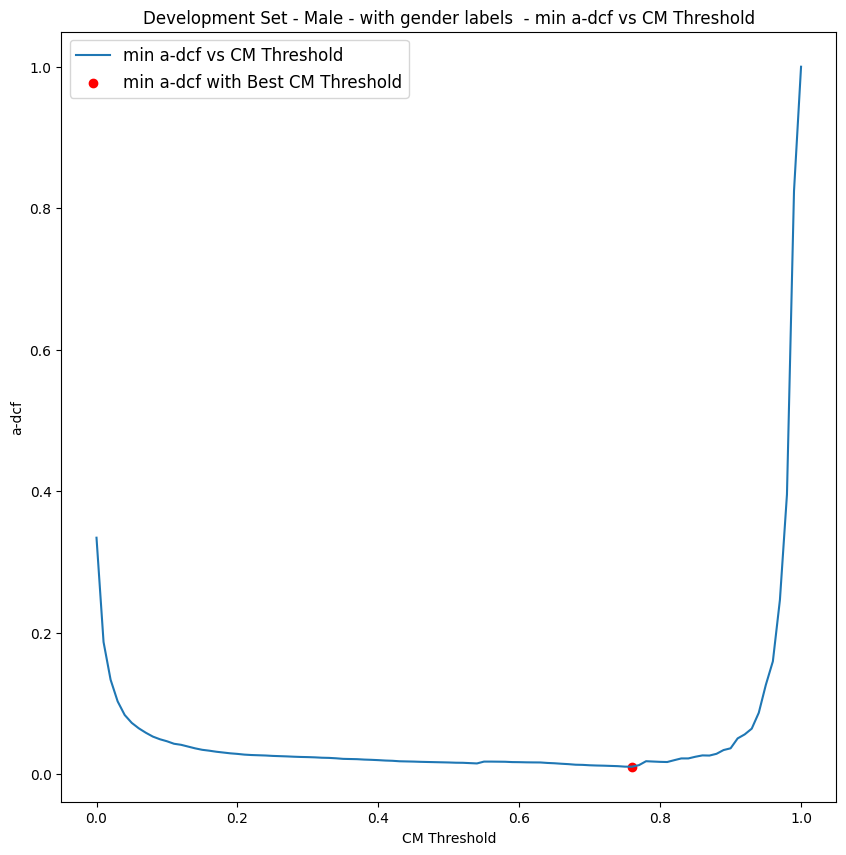

In [438]:
cm_filesname = Dev_dataset_all.name[(Dev_dataset_all.sex == 'male')]
cm_scores = 1-score_dev_male.flatten()
asv_scores = results.loc[(results['its_male_ground_truth'] == 'male')]["asv_score_male"].values
asv_speakers =  results.loc[(results['its_male_ground_truth'] == 'male')]["speaker_id_male"].values
asv_filenames = results.loc[(results['its_male_ground_truth'] == 'male')]["file_name"].values
asv_labels = results.loc[(results['its_male_ground_truth'] == 'male')]["asv_label"].values
title = "Development Set - Male - with gender labels  - min a-dcf vs CM Threshold"
adjusted_scores_male_dev, adjusted_labels_male_dev, adjusted_speakers_male_dev, adjusted_filename_male_dev, global_min_a_dcf_male_dev, global_min_a_dcf_thresh_male_dev,all_a_dcf,all_a_dcf_thresh = compute_a_dcf(cm_filesname, cm_scores, asv_speakers,asv_scores,asv_labels, asv_filenames,title = title,gender= 'male')

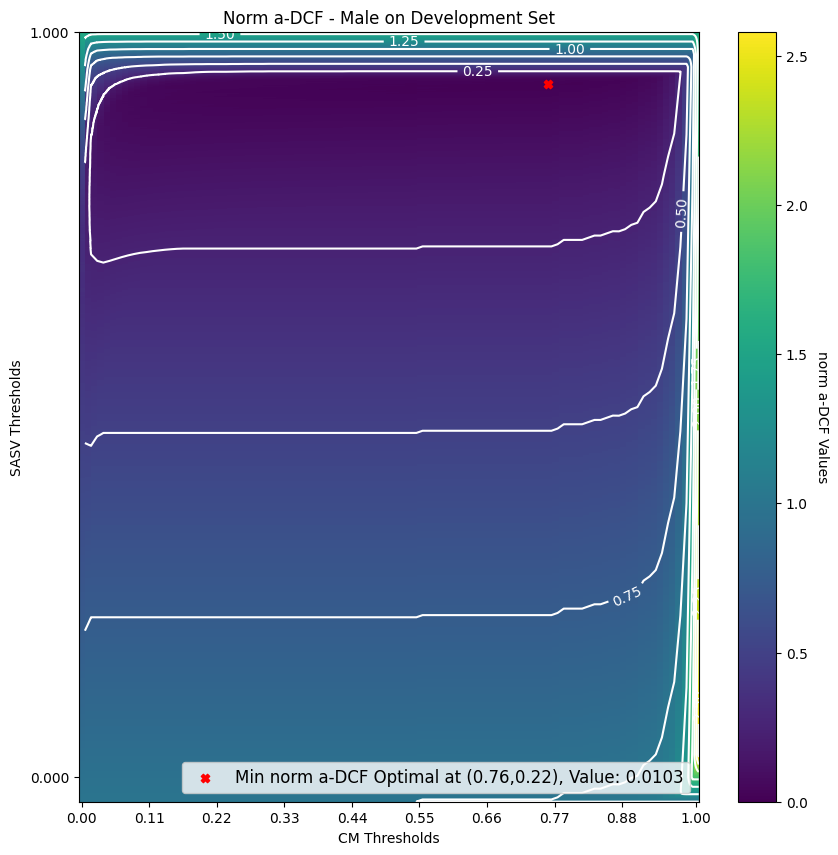

In [439]:
min_index = np.unravel_index(np.nanargmin(all_a_dcf), all_a_dcf.shape)
point_x_index = min_index[0]
point_y_index = min_index[1]

heatmap_norm_adcf(list_aDCF_norm = np.array(all_a_dcf),cm_thresholds = np.array(np.arange(0, 1.01, 0.1).tolist()),sasv_thresholds = all_a_dcf_thresh,target_values =  [0,0.5,1],title ="Norm a-DCF - Male on Development Set",point_x_index= point_x_index, point_y_index= point_y_index,point_x_constrained=None,point_y_constrained=None,value = None,defualt_show = 'male')

In [440]:
results

,file_name,its_male,its_male_ground_truth,its_spoof_male,spoof_score_male,its_spoof_female,spoof_score_female,spoof_ground_truth,asv_score_male,asv_score_female,speaker_id_male,speaker_id_female,find_speaker_in_enroll_male,find_speaker_in_enroll_female,asv_label,attack_type,in_cm_protocol
0,LA_D_4004968,True,male,False,0.006150,False,-0.912122,False,0.561741,0.000000,LA_0073,None,True,False,target,none,True
1,LA_D_6027798,True,male,False,0.006148,False,-0.935269,False,0.703008,0.000000,LA_0073,None,True,False,target,none,True
2,LA_D_3986002,True,male,False,0.007109,False,-0.915763,False,0.675328,0.000000,LA_0073,None,True,False,target,none,True
3,LA_D_9330492,True,male,False,0.005233,False,-0.903112,False,0.539661,0.000000,LA_0073,None,True,False,target,none,True
4,LA_D_1364611,True,male,False,0.007441,False,-0.909984,False,0.506510,0.000000,LA_0073,None,True,False,target,none,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29543,LA_D_6306347,False,female,True,0.959626,True,0.567938,True,0.000000,0.214340,None,LA_0069,False,True,spoof,A06,True
29544,LA_D_3133630,False,female,True,0.981835,True,0.644323,True,0.000000,0.155820,None,LA_0069,False,True,spoof,A05,True
29545,LA_D_9909170,False,female,True,0.979534,True,0.504778,True,0.000000,0.072316,None,LA_0069,False,True,spoof,A06,True
29546,LA_D_3790932,False,female,True,0.991858,True,0.779713,True,0.000000,0.182552,None,LA_0069,False,True,spoof,A05,True


### with pred of gender:

In [441]:
labels_dev_male_gender_classification = torch.Tensor(Dev_dataset_all.is_spoofed[gender_model.predict(Dev_dataset_all.data_for_gender_classification) == 1]).cpu().numpy().copy()
total_data = torch.Tensor(Dev_dataset_all.data[gender_model.predict(Dev_dataset_all.data_for_gender_classification) == 1]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    score_dev_male_gender_classification = torch.sigmoid(spoof_model_male(torch.Tensor(total_data).to(device)))
    
score_dev_male_gender_classification = score_dev_male_gender_classification.cpu().numpy().copy()

dev_male_eer, _ = my_functions.compute_eer(labels_dev_male_gender_classification,score_dev_male_gender_classification) # compute equal error rate

print(f"\tDev male EER: ({100*dev_male_eer}%)")



	Dev male EER: (0.7981601731367872%)


In [442]:

bonafide_score_cm_male_dev = 1-score_dev_male_gender_classification[labels_dev_male == 0].flatten()
spoof_score_cm_male_dev = 1- score_dev_male_gender_classification[labels_dev_male == 1].flatten()
Prior_spoof = 0.05
target_scores_male_dev = results.loc[(results['asv_label'] ==  "target") & (results['its_male'] == True) ]["asv_score_male"].values
nontarget_scores_male_dev = results.loc[(results['asv_label'] == "nontarget") & (results['its_male'] == True) ]["asv_score_male"].values
spoof_scores_male_dev = results.loc[(results['asv_label'] ==  "spoof") & (results['its_male'] == True)]["asv_score_male"].values
list_asv_score = [0.261]
type = 'constrained'
list_tDCF_norm_male_dev ,list_CM_thresholds_male_dev,list_tDCF_male_dev   = compute_t_dcf(bonafide_score_cm_male_dev,spoof_score_cm_male_dev,Prior_spoof,target_scores_male_dev,nontarget_scores_male_dev,spoof_scores_male_dev,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=868, Nspoof=7392] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  3.08466 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.261
the CM thresholds is:  [3.23759556e-04 1.32375956e-03 1.48350000e-03 ... 9.96420860e-01
 9.96460497e-01 9.96598303e-01]
the CM threshold min is: 0.7655534744262695

a-DCF: 0.33411, threshold: 0.43342
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.18662, threshold: 0.37886
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.13332, threshold: 0.37567
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.10274, threshold: 0.37567
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.08348, threshold: 0.36241
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.07233, threshold: 0.36241
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.06462, threshold: 0.35626
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.05837, threshold: 0.35626
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.05291, threshold: 0.35606
CostModel(Pspf=0.05, Pnontrg=

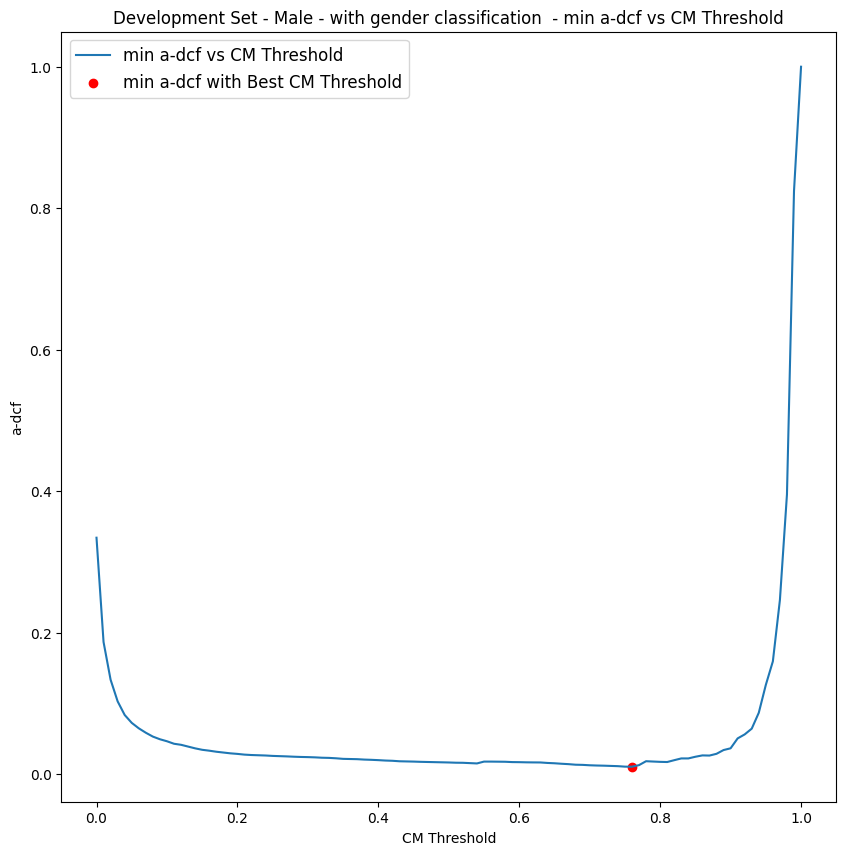

In [443]:
cm_filesname = Dev_dataset_all.name[(Dev_dataset_all.sex == 'male')]
cm_scores = 1-score_dev_male.flatten()
asv_scores = results.loc[(results['its_male'] == True)]["asv_score_male"].values
asv_speakers =  results.loc[(results['its_male'] == True)]["speaker_id_male"].values
asv_filenames = results.loc[(results['its_male'] == True)]["file_name"].values
asv_labels = results.loc[(results['its_male'] == True)]["asv_label"].values
title = "Development Set - Male - with gender classification  - min a-dcf vs CM Threshold"
adjusted_scores_male_dev, adjusted_labels_male_dev, adjusted_speakers_male_dev, adjusted_filename_male_dev, global_min_a_dcf_male_dev, global_min_a_dcf_thresh_male_dev,all_a_dcf,all_a_dcf_thresh = compute_a_dcf(cm_filesname, cm_scores, asv_speakers,asv_scores,asv_labels, asv_filenames,title = title,gender= 'male')

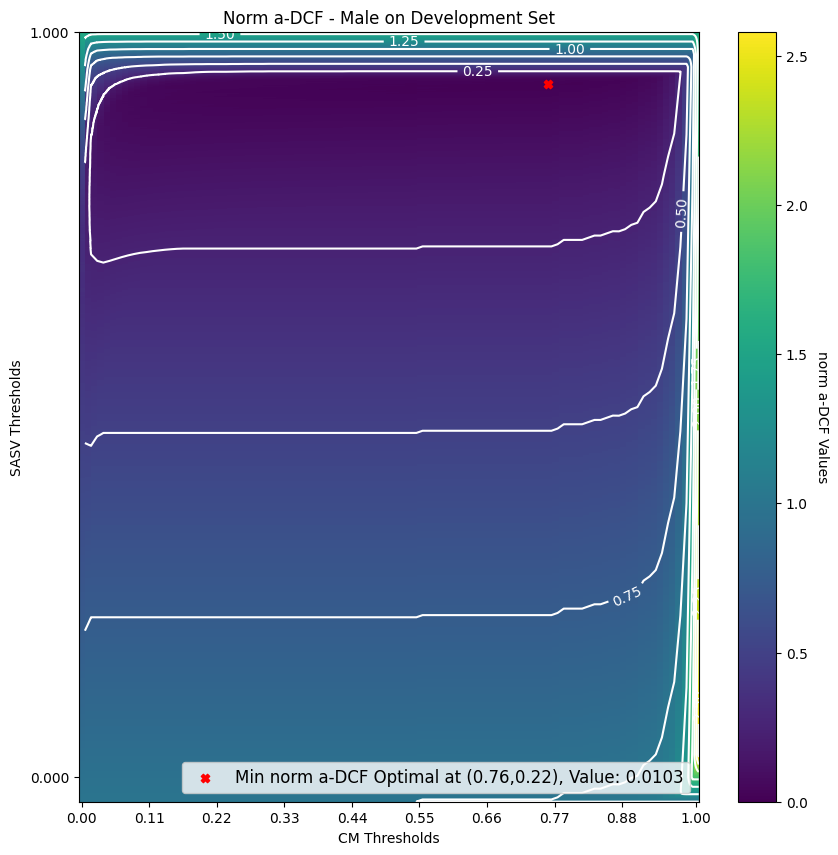

In [444]:
min_index = np.unravel_index(np.nanargmin(all_a_dcf), all_a_dcf.shape)
point_x_index = min_index[0]
point_y_index = min_index[1]

heatmap_norm_adcf(list_aDCF_norm = np.array(all_a_dcf),cm_thresholds = np.array(np.arange(0, 1.01, 0.01).tolist()),sasv_thresholds = all_a_dcf_thresh,target_values =  [0,0.5,1],title ="Norm a-DCF - Male on Development Set",point_x_index= point_x_index, point_y_index= point_y_index,point_x_constrained=None,point_y_constrained=None,value = None,defualt_show = 'male')

## Female - DEV:

### with labels of gender:

In [445]:
labels_dev_female = torch.Tensor(Dev_dataset_all.is_spoofed[(Dev_dataset_all.sex == 'female').values].values).cpu().numpy().copy()
total_data = torch.Tensor(Dev_dataset_all.data[(Dev_dataset_all.sex == 'female').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    output = spoof_model_female(torch.Tensor(total_data).to(device))
    _ , score_dev_female = spoof_model_female.loss(torch.Tensor(output).to(device),None)
    score_dev_female = -1*score_dev_female
    
score_dev_female = score_dev_female.cpu().numpy().copy()

eer, thresh = my_functions.compute_eer(labels_dev_female,score_dev_female) # compute equal error rate

print(f"\tDev Female EER:({100*eer}%)")

	Dev Female EER:(0.0%)


c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:653: RuntimeWarning: divide by zero encountered in true_divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:656: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


In [446]:

bonafide_score_cm_female_dev = score_dev_female[labels_dev_female == 0].flatten()
bonafide_score_cm_female_dev = -1*bonafide_score_cm_female_dev

spoof_score_cm_female_dev = score_dev_female[labels_dev_female == 1].flatten()
spoof_score_cm_female_dev = -1*spoof_score_cm_female_dev
Prior_spoof = 0.05
target_scores_female_dev = results.loc[(results['asv_label'] ==  "target") & (results['its_male_ground_truth'] == 'female') ]["asv_score_female"].values
nontarget_scores_female_dev = results.loc[(results['asv_label'] == "nontarget") & (results['its_male_ground_truth'] == 'female') ]["asv_score_female"].values
spoof_scores_female_dev = results.loc[(results['asv_label'] ==  "spoof") & (results['its_male_ground_truth'] == 'female')]["asv_score_female"].values
list_asv_score = [0.397]
type = 'constrained'
list_tDCF_norm_female_dev ,list_CM_thresholds_female_dev,list_tDCF_female_dev  = compute_t_dcf(bonafide_score_cm_female_dev,spoof_score_cm_female_dev,Prior_spoof,target_scores_female_dev,nontarget_scores_female_dev,spoof_scores_female_dev,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=1680, Nspoof=14904] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  5.14878 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.397
the CM thresholds is:  [-0.82879741 -0.82779741 -0.82524741 ...  0.94876456  0.94895041
  0.95111585]
the CM threshold min is: 0.5543830394744873
the tDCF_norm i

a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=

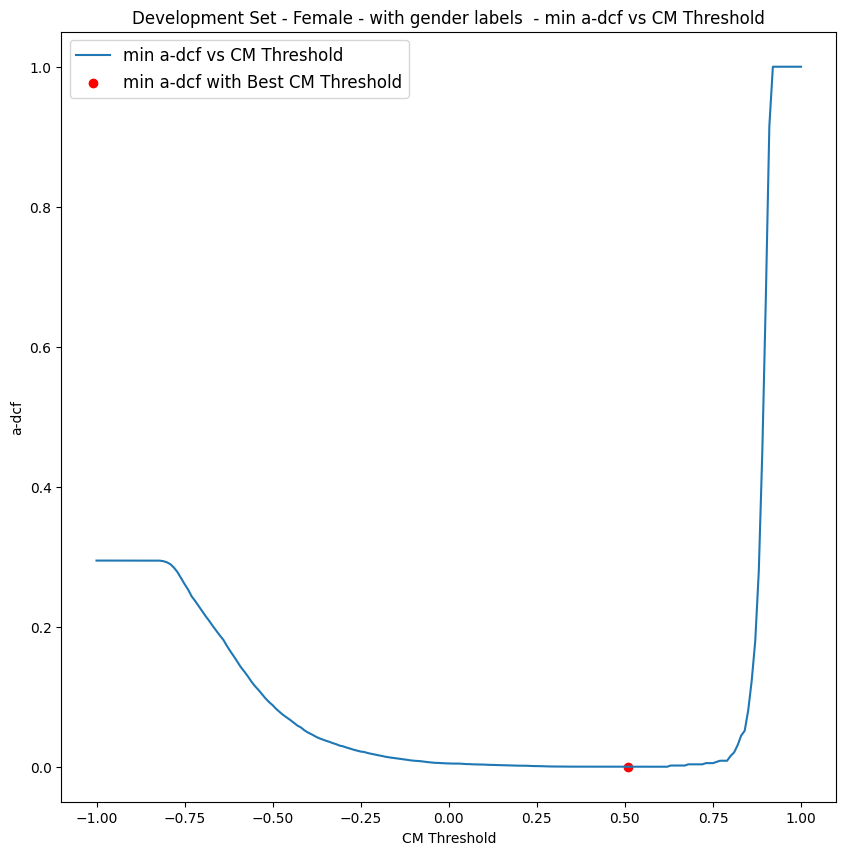

In [447]:
cm_filesname = Dev_dataset_all.name[(Dev_dataset_all.sex == 'female')]
cm_scores = -1*score_dev_female.flatten()
asv_scores = results.loc[(results['its_male_ground_truth'] == 'female')]["asv_score_female"].values
asv_speakers =  results.loc[(results['its_male_ground_truth'] == 'female')]["speaker_id_female"].values
asv_filenames = results.loc[(results['its_male_ground_truth'] == 'female')]["file_name"].values
asv_labels = results.loc[(results['its_male_ground_truth'] == 'female')]["asv_label"].values
title = "Development Set - Female - with gender labels  - min a-dcf vs CM Threshold"
adjusted_scores_female_dev, adjusted_labels_female_dev, adjusted_speakers_female_dev, adjusted_filename_female_dev, global_min_a_dcf_female_dev, global_min_a_dcf_thresh_female_dev,all_a_dcf,all_a_dcf_thresh = compute_a_dcf(cm_filesname, cm_scores, asv_speakers,asv_scores,asv_labels, asv_filenames,title = title,gender= 'female')

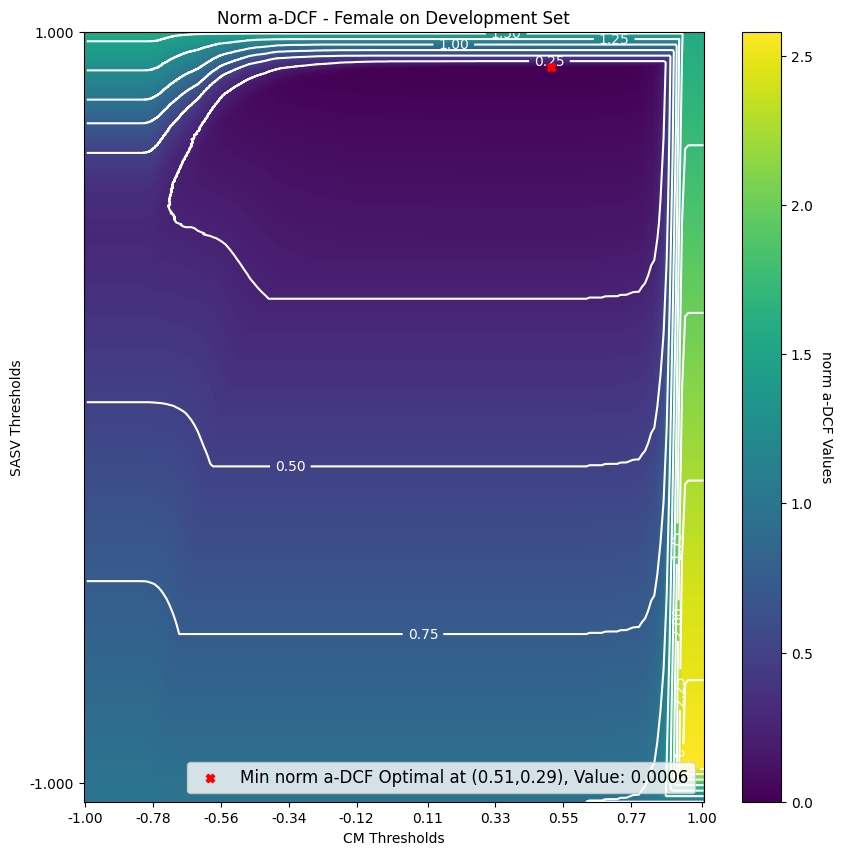

In [448]:
min_index = np.unravel_index(np.nanargmin(all_a_dcf), all_a_dcf.shape)
point_x_index = min_index[0]
point_y_index = min_index[1]

heatmap_norm_adcf(list_aDCF_norm = np.array(all_a_dcf),cm_thresholds = np.array(np.arange(0, 1.01, 0.01).tolist()),sasv_thresholds = all_a_dcf_thresh,target_values =  [0,0.5,1],title ="Norm a-DCF - Female on Development Set",point_x_index= point_x_index, point_y_index= point_y_index,point_x_constrained=None,point_y_constrained=None,value = None,defualt_show = 'female')

### with pred of gender:

In [449]:
labels_dev_female_gender_classification = torch.Tensor(Dev_dataset_all.is_spoofed[gender_model.predict(Dev_dataset_all.data_for_gender_classification) == 0].values).cpu().numpy().copy()
total_data = torch.Tensor(Dev_dataset_all.data[gender_model.predict(Dev_dataset_all.data_for_gender_classification) == 0]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    output = spoof_model_female(torch.Tensor(total_data).to(device))
    _ , score_dev_female_gender_classification = spoof_model_female.loss(torch.Tensor(output).to(device),None)
    score_dev_female_gender_classification = -1*score_dev_female_gender_classification
    
score_dev_female_gender_classification = score_dev_female_gender_classification.cpu().numpy().copy()

eer, thresh = my_functions.compute_eer(labels_dev_female_gender_classification,score_dev_female_gender_classification) # compute equal error rate

print(f"\tDev Female EER:({100*eer}%)")

	Dev Female EER:(0.0%)


c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:653: RuntimeWarning: divide by zero encountered in true_divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:656: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


In [450]:
bonafide_score_cm_female_dev = score_dev_female[labels_dev_female_gender_classification == 0].flatten()
bonafide_score_cm_female_dev = -1*bonafide_score_cm_female_dev

spoof_score_cm_female_dev = score_dev_female[labels_dev_female_gender_classification == 1].flatten()
spoof_score_cm_female_dev = -1*spoof_score_cm_female_dev
Prior_spoof = 0.05
target_scores_female_dev = results.loc[(results['asv_label'] ==  "target") & (results['its_male'] == False) ]["asv_score_female"].values
nontarget_scores_female_dev = results.loc[(results['asv_label'] == "nontarget") & (results['its_male'] == False) ]["asv_score_female"].values
spoof_scores_female_dev = results.loc[(results['asv_label'] ==  "spoof") & (results['its_male'] == False)]["asv_score_female"].values
list_asv_score = [0.397]
type = 'constrained'

list_tDCF_norm_female_dev ,list_CM_thresholds_female_dev,list_tDCF_female_dev = compute_t_dcf(bonafide_score_cm_female_dev,spoof_score_cm_female_dev,Prior_spoof,target_scores_female_dev,nontarget_scores_female_dev,spoof_scores_female_dev,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=1680, Nspoof=14904] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  5.14878 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.397
the CM thresholds is:  [-0.82879741 -0.82779741 -0.82524741 ...  0.94876456  0.94895041
  0.95111585]
the CM threshold min is: 0.5543830394744873
the tDCF_norm i

a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.29495, threshold: 0.45279
CostModel(Pspf=0.05, Pnontrg=

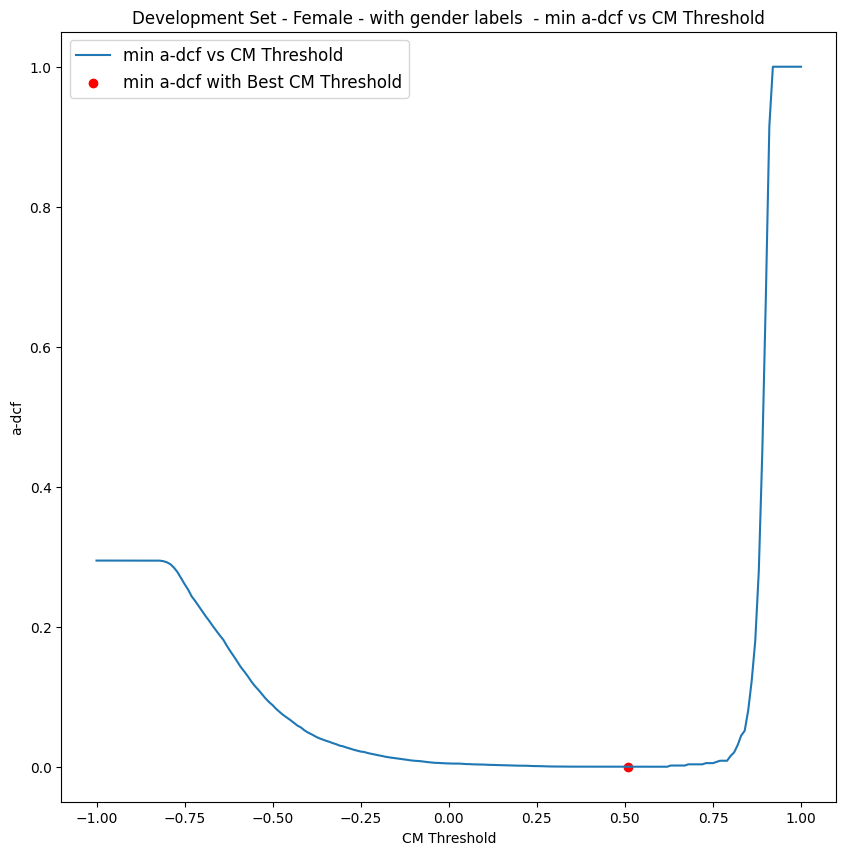

In [451]:
cm_filesname = Dev_dataset_all.name[(Dev_dataset_all.sex == 'female')]
cm_scores = -1*score_dev_female.flatten()
asv_scores = results.loc[(results['its_male'] == False)]["asv_score_female"].values
asv_speakers =  results.loc[(results['its_male'] == False)]["speaker_id_female"].values
asv_filenames = results.loc[(results['its_male'] == False)]["file_name"].values
asv_labels = results.loc[(results['its_male'] == False)]["asv_label"].values
title = "Development Set - Female - with gender labels  - min a-dcf vs CM Threshold"
adjusted_scores_female_dev, adjusted_labels_female_dev, adjusted_speakers_female_dev, adjusted_filename_female_dev, global_min_a_dcf_female_dev, global_min_a_dcf_thresh_female_dev,all_a_dcf,all_a_dcf_thresh = compute_a_dcf(cm_filesname, cm_scores, asv_speakers,asv_scores,asv_labels, asv_filenames,title = title,gender= 'female')

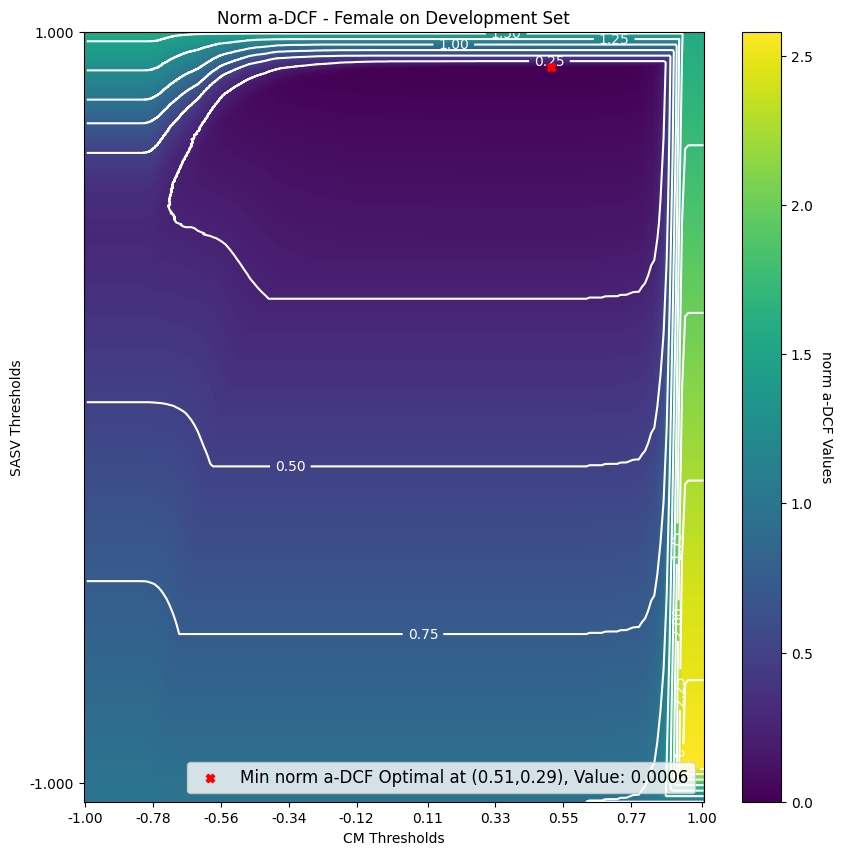

In [452]:
min_index = np.unravel_index(np.nanargmin(all_a_dcf), all_a_dcf.shape)
point_x_index = min_index[0]
point_y_index = min_index[1]

heatmap_norm_adcf(list_aDCF_norm = np.array(all_a_dcf),cm_thresholds = np.array(np.arange(0, 1.01, 0.01).tolist()),sasv_thresholds = all_a_dcf_thresh,target_values =  [0,0.5,1],title ="Norm a-DCF - Female on Development Set",point_x_index= point_x_index, point_y_index= point_y_index,point_x_constrained=None,point_y_constrained=None,value = None,defualt_show = 'female')

## Eval:

In [453]:
from sklearn.metrics.pairwise import cosine_similarity
import torchaudio
import tqdm
from ASV_utils.config_thr import pmf_both_thr_gender_val ,pmf_both_thr_spoof_test_male,pmf_both_thr_spoof_test_female

txt_file_path = "output.txt"
csv_file_path = "output.csv"
enrollment_male = enrollment_eval_male
enrollment_female = enrollment_eval_female
list_files = file_name_according_speaker_id_eval
data_set = Eval_dataset_all
asv_model = classifier
spoof_labels = spoof_label_eval
list_speaker_id = speaker_id_list_eval
list_asv_label = asv_label_eval

#results_eval = inference_system_cm_asv_avg_score(spoof_labels,list_speaker_id,list_asv_label,txt_file_path,csv_file_path,pmf_both_thr_gender_val,pmf_both_thr_spoof_test_male,pmf_both_thr_spoof_test_female,enrollment_male, enrollment_female, list_files, data_set, gender_model, spoof_model_male, spoof_model_female, asv_model, device, verbose = False, verbose_txt = False,verbose_csv = False)

In [454]:
from ASV_utils.tdcf_functions import compute_t_dcf


import pickle
with open('./dcf_and_tdcf/dcf_avg_score/pmf_both_tdcf/asv_protocol/objects_asv_and_cm_time_embeddings_eval_avg_score_both_asv_protocol.pkl', 'rb') as f:
    results_eval = pickle.load(f)


## Male - Eval:

### with labels of gender:

In [455]:
labels_eval_male = torch.Tensor(Eval_dataset_all.is_spoofed[(Eval_dataset_all.sex == 'male').values].values).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data[(Eval_dataset_all.sex == 'male').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    score_eval_male = torch.sigmoid(spoof_model_male(torch.Tensor(total_data).to(device)))
    
score_eval_male = score_eval_male.cpu().numpy().copy()

eer_eval_male, _ = my_functions.compute_eer(labels_eval_male,score_eval_male) # compute equal error rate

print(f"\t Eval Male EER: ({100*eer_eval_male}%)")

	 Eval Male EER: (9.203296703296708%)


In [456]:

bonafide_score_cm_male_eval = 1-score_eval_male[labels_eval_male == 0].flatten()
spoof_score_cm_male_eval = 1-score_eval_male[labels_eval_male == 1].flatten()
Prior_spoof = 0.05
target_scores_male_eval = results_eval.loc[(results_eval['asv_label'] ==  "target") & (results_eval['its_male_ground_truth'] == 'male') ]["asv_score_male"].values
nontarget_scores_male_eval = results_eval.loc[(results_eval['asv_label'] == "nontarget") & (results_eval['its_male_ground_truth'] == 'male') ]["asv_score_male"].values
spoof_scores_male_eval = results_eval.loc[(results_eval['asv_label'] ==  "spoof") & (results_eval['its_male_ground_truth'] == 'male')]["asv_score_male"].values
list_asv_score = [0.261,0.352]
type = 'constrained'
list_tDCF_norm_male_eval ,list_CM_thresholds_male_eval,list_tDCF_male_eval  = compute_t_dcf(bonafide_score_cm_male_eval,spoof_score_cm_male_eval,Prior_spoof,target_scores_male_eval,nontarget_scores_male_eval,spoof_scores_male_eval,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=2283, Nspoof=19656] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.46362 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.261
the CM thresholds is:  [3.27395439e-04 1.32739544e-03 1.33728981e-03 ... 9.96948719e-01
 9.97036994e-01 9.97085333e-01]
the CM threshold min is: 0.87405800819396

a-DCF: 0.54111, threshold: 0.48423
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.41419, threshold: 0.42873
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.39189, threshold: 0.42192
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.37859, threshold: 0.42192
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.36709, threshold: 0.42192
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.35619, threshold: 0.42192
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.34563, threshold: 0.42192
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.33717, threshold: 0.42192
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.32884, threshold: 0.37558
CostModel(Pspf=0.05, Pnontrg=

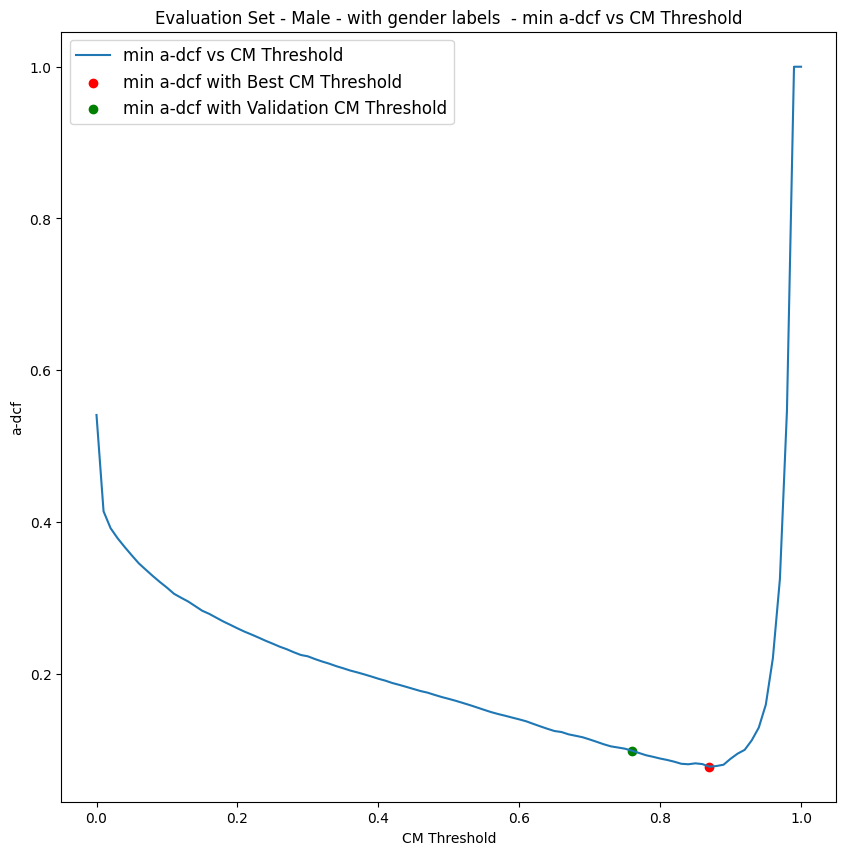

In [457]:
cm_filesname = Eval_dataset_all.name[(Eval_dataset_all.sex == 'male')]
cm_scores = 1-score_eval_male.flatten()
asv_scores = results_eval.loc[(results_eval['its_male_ground_truth'] == 'male')]["asv_score_male"].values
asv_speakers =  results_eval.loc[(results_eval['its_male_ground_truth'] == 'male')]["speaker_id_male"].values
asv_filenames = results_eval.loc[(results_eval['its_male_ground_truth'] == 'male')]["file_name"].values
asv_labels = results_eval.loc[(results_eval['its_male_ground_truth'] == 'male')]["asv_label"].values
male_dev_cm_thr = 0.76 
title = "Evaluation Set - Male - with gender labels  - min a-dcf vs CM Threshold"
adjusted_scores_male_eval, adjusted_labels_male_eval, adjusted_speakers_male_eval, adjusted_filename_male_eval, global_min_a_dcf_male_eval, global_min_a_dcf_thresh_male_eval,all_a_dcf,all_a_dcf_thresh = compute_a_dcf(cm_filesname, cm_scores, asv_speakers,asv_scores,asv_labels, asv_filenames,val_CM_threshold = male_dev_cm_thr, title = title,gender= 'male')

In [458]:
point_y_constrained

29667

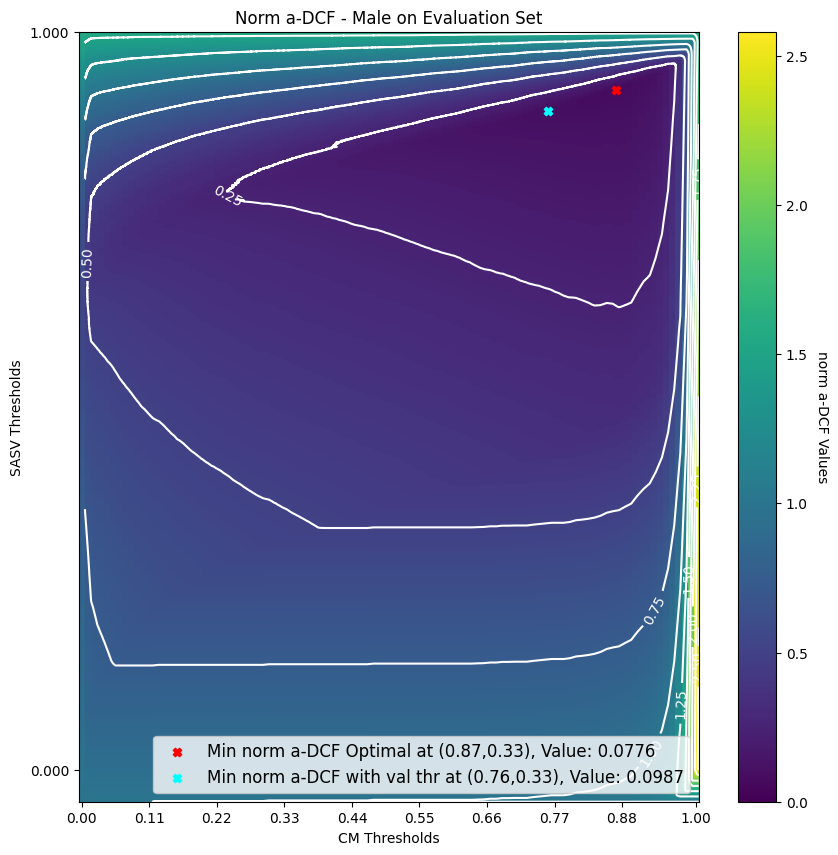

In [459]:
min_index = np.unravel_index(np.nanargmin(all_a_dcf), all_a_dcf.shape)
point_x_index = min_index[0]
point_y_index = min_index[1]
cm_thresholds = np.array(np.arange(0, 1.01, 0.01).tolist())
point_x_constrained = np.where(cm_thresholds == male_dev_cm_thr)[0][0]
point_y_constrained = np.nanargmin(np.array(all_a_dcf)[point_x_constrained])
heatmap_norm_adcf(list_aDCF_norm = np.array(all_a_dcf),cm_thresholds = cm_thresholds,sasv_thresholds = all_a_dcf_thresh,target_values =  [0,0.5,1],title ="Norm a-DCF - Male on Evaluation Set",point_x_index= point_x_index, point_y_index= point_y_index,point_x_constrained=point_x_constrained,point_y_constrained=point_y_constrained,value = None,defualt_show = 'male')

### with pred of gender:

In [460]:
labels_eval_male_gender_classification = torch.Tensor(Eval_dataset_all.is_spoofed[gender_model.predict(Eval_dataset_all.data_for_gender_classification) == 1]).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data[gender_model.predict(Eval_dataset_all.data_for_gender_classification) == 1]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    score_eval_male_gender_classification = torch.sigmoid(spoof_model_male(torch.Tensor(total_data).to(device)))
    
score_eval_male_gender_classification = score_eval_male_gender_classification.cpu().numpy().copy()

eval_male_eer, _ = my_functions.compute_eer(labels_eval_male_gender_classification,score_eval_male_gender_classification) # compute equal error rate

print(f"\tEval male with gender classification EER: ({100*eval_male_eer}%) ")

	Eval male with gender classification EER: (9.069893266440404%) 


In [461]:

bonafide_score_cm_male_eval = 1-score_eval_male_gender_classification[labels_eval_male_gender_classification == 0].flatten()
spoof_score_cm_male_eval = 1-score_eval_male_gender_classification[labels_eval_male_gender_classification == 1].flatten()

Prior_spoof = 0.05
target_scores_male_eval = results_eval.loc[(results_eval['asv_label'] ==  "target") & (results_eval['its_male'] == True) ]["asv_score_male"].values
nontarget_scores_male_eval = results_eval.loc[(results_eval['asv_label'] == "nontarget") & (results_eval['its_male'] == True) ]["asv_score_male"].values
spoof_scores_male_eval = results_eval.loc[(results_eval['asv_label'] ==  "spoof") & (results_eval['its_male'] == True)]["asv_score_male"].values
list_asv_score = [0.261,0.352]
type = 'constrained'
list_tDCF_norm_male_eval ,list_CM_thresholds_male_eval,list_tDCF_male_eval  = compute_t_dcf(bonafide_score_cm_male_eval,spoof_score_cm_male_eval,Prior_spoof,target_scores_male_eval,nontarget_scores_male_eval,spoof_scores_male_eval,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=2288, Nspoof=20331] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.55266 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.261
the CM thresholds is:  [3.27395439e-04 1.32739544e-03 1.33728981e-03 ... 9.96948719e-01
 9.97036994e-01 9.97085333e-01]
the CM threshold min is: 0.87405800819396

a-DCF: 0.53152, threshold: 0.48423
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.40806, threshold: 0.42873
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.38653, threshold: 0.42192
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.37405, threshold: 0.42192
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.36343, threshold: 0.42192
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.35293, threshold: 0.42192
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.34288, threshold: 0.42192
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.33472, threshold: 0.37558
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.32604, threshold: 0.37558
CostModel(Pspf=0.05, Pnontrg=

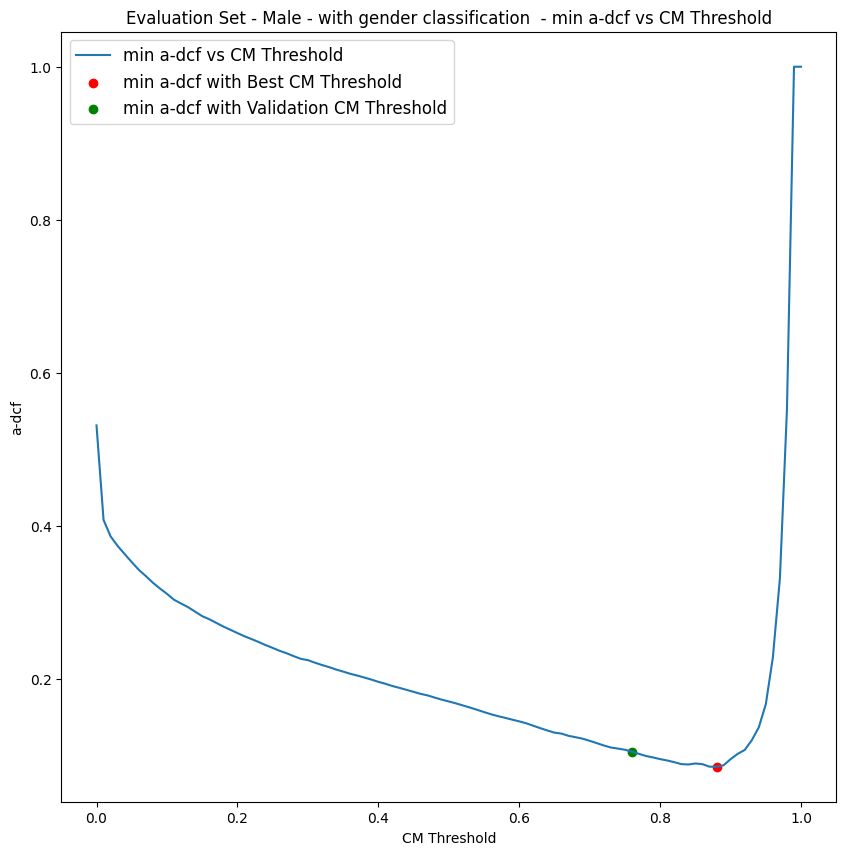

In [462]:
cm_filesname = Eval_dataset_all.name[gender_model.predict(Eval_dataset_all.data_for_gender_classification) == 1]
cm_scores = 1-score_eval_male_gender_classification.flatten()
asv_scores = results_eval.loc[(results_eval['its_male'] == True)]["asv_score_male"].values
asv_speakers =  results_eval.loc[(results_eval['its_male'] == True)]["speaker_id_male"].values
asv_filenames = results_eval.loc[(results_eval['its_male'] == True)]["file_name"].values
asv_labels = results_eval.loc[(results_eval['its_male'] == True)]["asv_label"].values
male_dev_cm_thr = 0.76
title = "Evaluation Set - Male - with gender classification  - min a-dcf vs CM Threshold"
adjusted_scores_male_eval, adjusted_labels_male_eval, adjusted_speakers_male_eval, adjusted_filename_male_eval, global_min_a_dcf_male_eval, global_min_a_dcf_thresh_male_eval,all_a_dcf,all_a_dcf_thresh = compute_a_dcf(cm_filesname, cm_scores, asv_speakers,asv_scores,asv_labels, asv_filenames,val_CM_threshold = male_dev_cm_thr, title = title,gender= 'male')

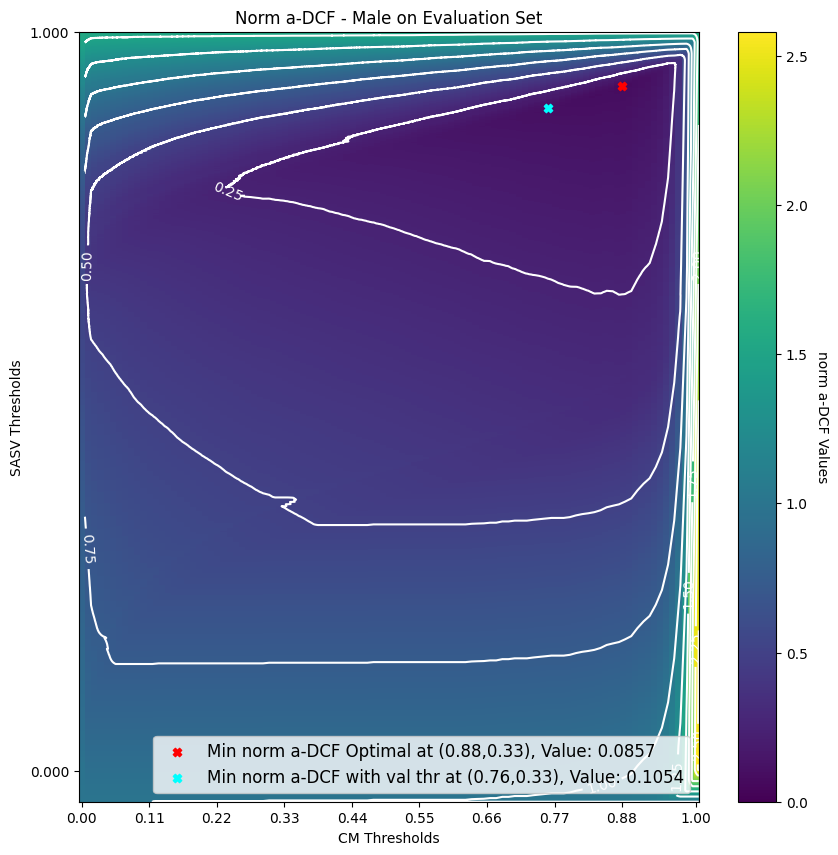

In [463]:
min_index = np.unravel_index(np.nanargmin(all_a_dcf), all_a_dcf.shape)
point_x_index = min_index[0]
point_y_index = min_index[1]
cm_thresholds = np.array(np.arange(0, 1.01, 0.01).tolist())
point_x_constrained = np.where(cm_thresholds == male_dev_cm_thr)[0][0]
point_y_constrained = np.nanargmin(np.array(all_a_dcf)[point_x_constrained])
heatmap_norm_adcf(list_aDCF_norm = np.array(all_a_dcf),cm_thresholds = cm_thresholds,sasv_thresholds = all_a_dcf_thresh,target_values =  [0,0.5,1],title ="Norm a-DCF - Male on Evaluation Set",point_x_index= point_x_index, point_y_index= point_y_index,point_x_constrained=point_x_constrained,point_y_constrained=point_y_constrained,value = None,defualt_show = 'male')

## Female - Eval:

### with labels of gender:

In [464]:
labels_eval_female = torch.Tensor(Eval_dataset_all.is_spoofed[(Eval_dataset_all.sex == 'female').values].values).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data[(Eval_dataset_all.sex == 'female').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    output = spoof_model_female(torch.Tensor(total_data).to(device))
    _ , score_eval_female = spoof_model_female.loss(torch.Tensor(output).to(device),None)
    score_eval_female = -1*score_eval_female
    
score_eval_female = score_eval_female.cpu().numpy().copy()

eer_eval_female, _ = my_functions.compute_eer(labels_eval_female,score_eval_female) # compute equal error rate

print(f"\tEval Female labels gender EER: ({eer_eval_female}%)")

	Eval Female labels gender EER: (0.10177271288382395%)


In [465]:
bonafide_score_cm_female_eval = score_eval_female[labels_eval_female == 0]
bonafide_score_cm_female_eval = -1*bonafide_score_cm_female_eval

spoof_score_cm_female_eval = score_eval_female[labels_eval_female == 1]
spoof_score_cm_female_eval  = -1*spoof_score_cm_female_eval

Prior_spoof = 0.05

target_scores_female_eval = results_eval.loc[(results_eval['asv_label'] ==  "target") & (results_eval['its_male_ground_truth'] == 'female') ]["asv_score_female"].values
nontarget_scores_female_eval = results_eval.loc[(results_eval['asv_label'] == "nontarget") & (results_eval['its_male_ground_truth'] == 'female') ]["asv_score_female"].values
spoof_scores_female_eval = results_eval.loc[(results_eval['asv_label'] ==  "spoof") & (results_eval['its_male_ground_truth'] == 'female')]["asv_score_female"].values

list_asv_score = [0.397,0.401]
type = 'constrained'
list_tDCF_norm_female_eval ,list_CM_thresholds_female_eval,list_tDCF_female_eval  = compute_t_dcf(bonafide_score_cm_female_eval,spoof_score_cm_female_eval,Prior_spoof,target_scores_female_eval,nontarget_scores_female_eval,spoof_scores_female_eval,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=5072, Nspoof=44226] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.97596 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.397
the CM thresholds is:  [-0.83954342 -0.83854342 -0.83505869 ...  0.95363593  0.95442975
  0.95455223]
the CM threshold min is: 0.7075192928314209
the tDCF_norm i

a-DCF: 0.48254, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48254, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48254, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48254, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48254, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48254, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48254, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48254, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48254, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=

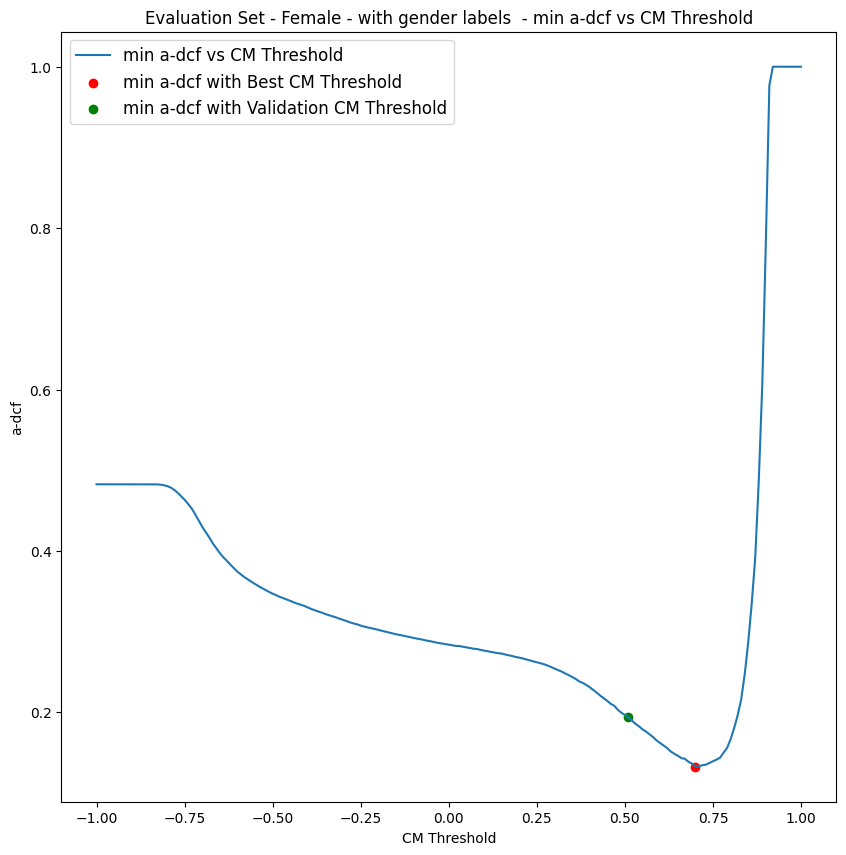

In [466]:
cm_filesname = Eval_dataset_all.name[(Eval_dataset_all.sex == 'female').values]
cm_scores = -1*score_eval_female.flatten()
asv_scores = results_eval.loc[(results_eval['its_male_ground_truth'] == 'female')]["asv_score_female"].values
asv_speakers =  results_eval.loc[(results_eval['its_male_ground_truth'] == 'female')]["speaker_id_female"].values
asv_filenames = results_eval.loc[(results_eval['its_male_ground_truth'] == 'female')]["file_name"].values
asv_labels = results_eval.loc[(results_eval['its_male_ground_truth'] == 'female')]["asv_label"].values
female_dev_cm_thr = 0.5100000000000013 
title = "Evaluation Set - Female - with gender labels  - min a-dcf vs CM Threshold"
adjusted_scores_female_eval, adjusted_labels_female_eval, adjusted_speakers_female_eval, adjusted_filename_female_eval, global_min_a_dcf_female_eval, global_min_a_dcf_thresh_female_eval,all_a_dcf,all_a_dcf_thresh = compute_a_dcf(cm_filesname, cm_scores, asv_speakers,asv_scores,asv_labels, asv_filenames,val_CM_threshold = female_dev_cm_thr, title = title,gender= 'female')

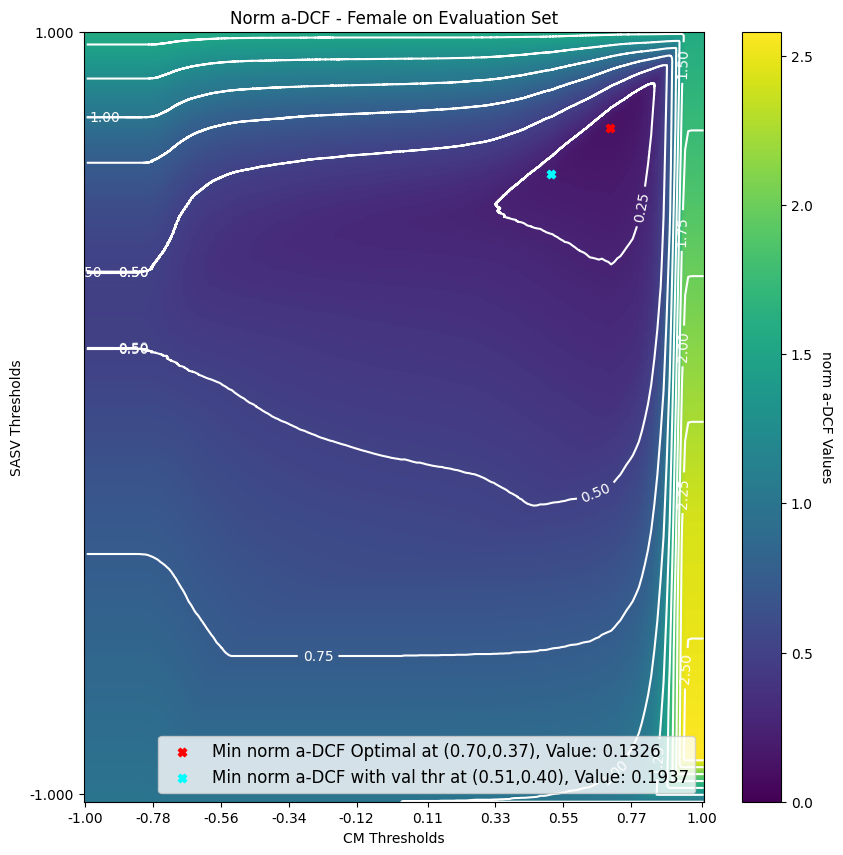

In [467]:
min_index = np.unravel_index(np.nanargmin(all_a_dcf), all_a_dcf.shape)
point_x_index = min_index[0]
point_y_index = min_index[1]
cm_thresholds = np.array(np.arange(-1, 1.01, 0.01).tolist())
point_x_constrained = np.where(cm_thresholds == female_dev_cm_thr)[0][0]
point_y_constrained = np.nanargmin(np.array(all_a_dcf)[point_x_constrained])
heatmap_norm_adcf(list_aDCF_norm = np.array(all_a_dcf),cm_thresholds = cm_thresholds,sasv_thresholds = all_a_dcf_thresh,target_values =  [0,0.5,1],title ="Norm a-DCF - Female on Evaluation Set",point_x_index= point_x_index, point_y_index= point_y_index,point_x_constrained=point_x_constrained,point_y_constrained=point_y_constrained,value = None,defualt_show = 'female')

### with pred of gender:

In [468]:
labels_eval_female_gender_classification = torch.Tensor(Eval_dataset_all.is_spoofed[gender_model.predict(Eval_dataset_all.data_for_gender_classification) == 0].values).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data[gender_model.predict(Eval_dataset_all.data_for_gender_classification) == 0]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    output = spoof_model_female(torch.Tensor(total_data).to(device))
    _ , score_eval_female_gender_classification = spoof_model_female.loss(torch.Tensor(output).to(device),None)
    score_eval_female_gender_classification = -1*score_eval_female_gender_classification
    
score_eval_female_gender_classification = score_eval_female_gender_classification.cpu().numpy().copy()

eer, _ = my_functions.compute_eer(labels_eval_female_gender_classification,score_eval_female_gender_classification) # compute equal error rate

print(f"\tDev Female EER:({100*eer}%)")

	Dev Female EER:(10.318936419363473%)


In [469]:
bonafide_score_cm_female_eval = score_eval_female_gender_classification[labels_eval_female_gender_classification == 0]
bonafide_score_cm_female_eval = -1*bonafide_score_cm_female_eval

spoof_score_cm_female_eval = score_eval_female_gender_classification[labels_eval_female_gender_classification == 1]
spoof_score_cm_female_eval  = -1*spoof_score_cm_female_eval

Prior_spoof = 0.05

target_scores_female_eval = results_eval.loc[(results_eval['asv_label'] ==  "target") & (results_eval['its_male'] == False) ]["asv_score_female"].values
nontarget_scores_female_eval = results_eval.loc[(results_eval['asv_label'] == "nontarget") & (results_eval['its_male'] == False) ]["asv_score_female"].values
spoof_scores_female_eval = results_eval.loc[(results_eval['asv_label'] ==  "spoof") & (results_eval['its_male'] == False)]["asv_score_female"].values

list_asv_score = [0.397,0.401]
type = 'constrained'
list_tDCF_norm_female_eval ,list_CM_thresholds_female_eval,list_tDCF_female_eval  = compute_t_dcf(bonafide_score_cm_female_eval,spoof_score_cm_female_eval,Prior_spoof,target_scores_female_eval,nontarget_scores_female_eval,spoof_scores_female_eval,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=5067, Nspoof=43551] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.95911 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.397
the CM thresholds is:  [-0.8395433  -0.8385433  -0.83505869 ...  0.95363587  0.95442975
  0.95455223]
the CM threshold min is: 0.7075192928314209
the tDCF_norm i

a-DCF: 0.48774, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48774, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48774, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48774, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48774, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48774, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48774, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48774, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48774, threshold: 0.48386
CostModel(Pspf=0.05, Pnontrg=

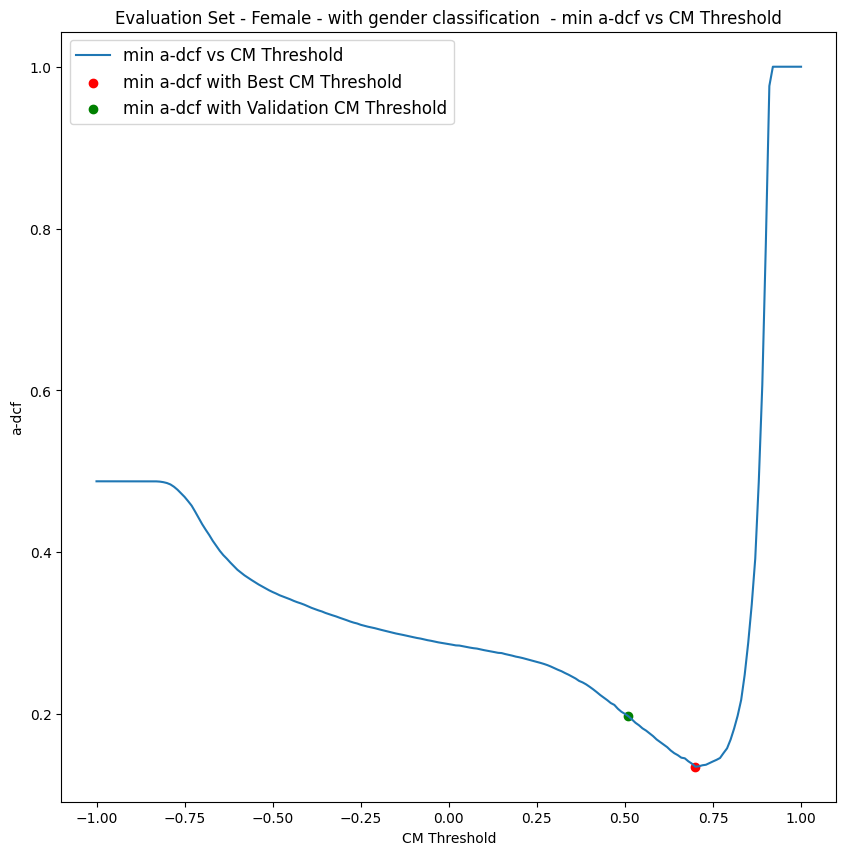

In [470]:
cm_filesname = Eval_dataset_all.name[gender_model.predict(Eval_dataset_all.data_for_gender_classification) == 0]
cm_scores = -1*score_eval_female_gender_classification.flatten()
asv_scores = results_eval.loc[(results_eval['its_male'] == False)]["asv_score_female"].values
asv_speakers =  results_eval.loc[(results_eval['its_male'] == False)]["speaker_id_female"].values
asv_filenames = results_eval.loc[(results_eval['its_male'] == False)]["file_name"].values
asv_labels = results_eval.loc[(results_eval['its_male'] == False)]["asv_label"].values
female_dev_cm_thr = 0.5100000000000013 
title = "Evaluation Set - Female - with gender classification  - min a-dcf vs CM Threshold"
adjusted_scores_female_eval, adjusted_labels_female_eval, adjusted_speakers_female_eval, adjusted_filename_female_eval, global_min_a_dcf_female_eval, global_min_a_dcf_thresh_female_eval,all_a_dcf,all_a_dcf_thresh = compute_a_dcf(cm_filesname, cm_scores, asv_speakers,asv_scores,asv_labels, asv_filenames,val_CM_threshold = female_dev_cm_thr, title = title,gender= 'female')

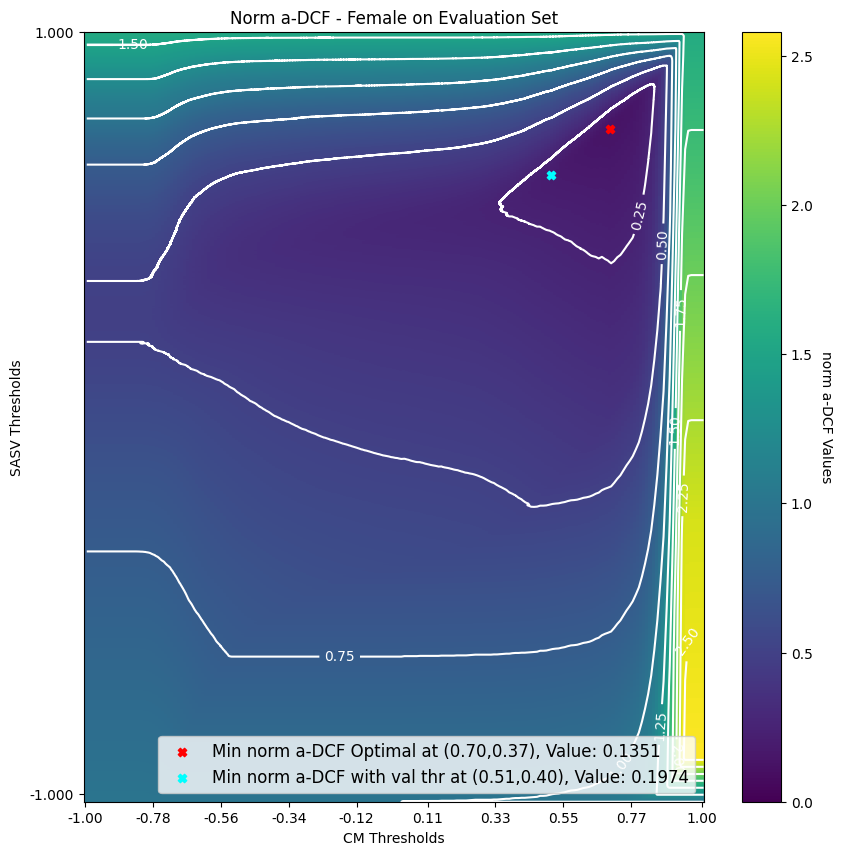

In [471]:
min_index = np.unravel_index(np.nanargmin(all_a_dcf), all_a_dcf.shape)
point_x_index = min_index[0]
point_y_index = min_index[1]
cm_thresholds = np.array(np.arange(-1, 1.01, 0.01).tolist())
point_x_constrained = np.where(cm_thresholds == female_dev_cm_thr)[0][0]
point_y_constrained = np.nanargmin(np.array(all_a_dcf)[point_x_constrained])
heatmap_norm_adcf(list_aDCF_norm = np.array(all_a_dcf),cm_thresholds = cm_thresholds,sasv_thresholds = all_a_dcf_thresh,target_values =  [0,0.5,1],title ="Norm a-DCF - Female on Evaluation Set",point_x_index= point_x_index, point_y_index= point_y_index,point_x_constrained=point_x_constrained,point_y_constrained=point_y_constrained,value = None,defualt_show = 'female')

## without Gender speration: 

In [472]:
import torch
import torch.nn as nn
from utils.AMSloss import AdMSoftmaxLoss
from utils.OCSoftmaxloss import OCSoftmax
import torch.nn as nn

import torch.nn as nn
class SubChannelNetwork(nn.Module):
    def __init__(self, input_channel_size, output_channel_size):
        super(SubChannelNetwork, self).__init__()
        self.input_layer = nn.Linear(input_channel_size, output_channel_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)
        self.BN_4 = nn.BatchNorm1d(output_channel_size) 
   
    def forward(self, x):
        res = x
        x = self.input_layer(x)
        x = self.BN_4(x) 
        x = self.sigmoid(x)
        x = self.dropout(x)
        x = res + x 
        return x

class DNN(nn.Module):
    def __init__(self, input_channel_size, num_subnetworks, output_channel_size, final_output_size, r_real , r_fake,alpha):
        super(DNN, self).__init__()
        self.SubChannelNetwork = nn.ModuleList([
            SubChannelNetwork(input_channel_size, output_channel_size) for _ in range(num_subnetworks)
        ])
        self.fc_between_subnet = nn.Linear(num_subnetworks * output_channel_size,80)
        self.BN = nn.BatchNorm1d(80)
        self.fc = nn.Linear(80, final_output_size)
        self.sigmoid = nn.Sigmoid()
        self.droupout = nn.Dropout(p=0.2)
        self.r_real = r_real
        self.r_fake = r_fake
        self.alpha = alpha
        self.loss = OCSoftmax(feat_dim = final_output_size, r_real = self.r_real, r_fake = self.r_fake, alpha = self.alpha)
        self.optimizer = None
        self.scheduler = None
        
        
    def forward(self, x):
        subnetwork_outputs = [self.SubChannelNetwork[idx](x[:, idx*input_channel_size:(idx+1)*input_channel_size].to(device)) for idx in range(len(self.SubChannelNetwork))]
        combined_output = torch.cat(subnetwork_outputs, dim=1)
        x = self.fc_between_subnet(combined_output)    
        x = self.BN(x)
        x = self.sigmoid(x)
        x = self.droupout(x)
        output = self.fc(x)
        return output 
    
    @staticmethod
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)


r_real = 0.9 
r_fake = 0.5
alpha = 20
input_channel_size = 10
output_channel_size = 10
num_SubChannelNetwork = 16
final_output_size = 16*2
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size,r_real = r_real , r_fake = r_fake,alpha = alpha)
model = model.to(device)


model = model.to(device) # send the model to the device

file_path = 'ECAPA_TDNN/inference_models/models_both_not_normalize/male_and_female_2_neorun_end_OCS_both_10_2.pkl'

# Load the variable from the pickle file
with open(file_path, 'rb') as file:
    model = pickle.load(file)

model.eval()

spoof_model = copy.deepcopy(model)


In [473]:
total_labels = torch.Tensor(Dev_dataset_all.is_spoofed.values).cpu().numpy().copy()
total_data = torch.Tensor(Dev_dataset_all.data_without_separation).cpu().numpy().copy()
with torch.no_grad():
    spoof_model = spoof_model.to(device)
    validation_output = spoof_model(torch.Tensor(total_data).to(device)).cpu()
    loss , validation_score = spoof_model.loss(torch.Tensor(validation_output).to(device),torch.LongTensor(total_labels).to(device))
    validation_score = -1*validation_score


test_score_total = validation_score.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels,test_score_total) # compute equal error rate
print(f"\tTest EER: ({100*eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (0.039246467900462476%) 	Test Threshold: -0.9427753686997667


In [474]:
total_labels = torch.Tensor(Eval_dataset_all.is_spoofed.values).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data_without_separation).cpu().numpy().copy()
with torch.no_grad():
    spoof_model = spoof_model.to(device)
    test_output = spoof_model(torch.Tensor(total_data).to(device))
    _ , test_score = spoof_model.loss(torch.Tensor(test_output).to(device),torch.LongTensor(total_labels).to(device))
    test_score = -1*test_score
    
test_score_total = test_score.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels,test_score_total) # compute equal error rate


print(f"\tTest EER: ({100*eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (10.273629504398746%) 	Test Threshold: -0.996142029976868


## Dev:

In [475]:
from sklearn.metrics.pairwise import cosine_similarity
import torchaudio
import tqdm
from ASV_utils.config_thr import pmf_both_thr_spoof_val_all

txt_file_path = "output.txt"
csv_file_path = "output.csv"
enrollment_all  = enrollment_dev_male + enrollment_dev_female
list_files = file_name_according_speaker_id_dev
data_set = Dev_dataset_all
asv_model = classifier
spoof_labels = spoof_label_dev
list_speaker_id = speaker_id_list_dev
list_asv_label = asv_label_dev

#results_dev_without_gender = inference_system_cm_asv_avg_score_without_gender(spoof_labels,list_speaker_id,list_asv_label,txt_file_path,csv_file_path,pmf_both_thr_spoof_val_all,enrollment_all, list_files, data_set, spoof_model, asv_model, device, verbose = False, verbose_txt = False,verbose_csv = False)

In [476]:

import pickle
#with open('results_dev_without_gender_avg_score_both_asv_protocol.pkl', 'wb') as f:
#    pickle.dump(results_dev_without_gender,f)
    

import pickle
file_path = "./dcf_and_tdcf\dcf_avg_score/pmf_both_tdcf/asv_protocol/results_dev_without_gender_avg_score_both_asv_protocol.pkl"
with open(file_path, 'rb') as file:
    results_dev_without_gender = pickle.load(file)


In [477]:
labels_dev_without_gender = torch.Tensor(Dev_dataset_all.is_spoofed.values).cpu().numpy().copy()
total_data = torch.Tensor(Dev_dataset_all.data_without_separation).cpu().numpy().copy()
with torch.no_grad():
    spoof_model = spoof_model.to(device)
    output = spoof_model(torch.Tensor(total_data).to(device)).cpu()
    _ , score_dev_without_gender  = spoof_model.loss(torch.Tensor(output).to(device),None)
    score_dev_without_gender = -1*score_dev_without_gender


score_dev_without_gender = score_dev_without_gender.cpu().numpy().copy()

eer_dev_without_gender, _ = my_functions.compute_eer(labels_dev_without_gender,score_dev_without_gender) # compute equal error rate
print(f"\tTest EER: ({100*eer_dev_without_gender}%)")

	Test EER: (0.039246467900462476%)


In [478]:
from ASV_utils.tdcf_functions import compute_t_dcf
gender = 'male'

check_male =(results_dev_without_gender['speaker_id'].isin(['LA_0073', 'LA_0071', 'LA_0070', 'LA_0076']))


bonafide_score_cm = score_dev_without_gender[(labels_dev_without_gender == 0) & (Dev_dataset_all.sex == gender)]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_dev_without_gender[(labels_dev_without_gender == 1) & (Dev_dataset_all.sex == gender)]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

target_scores = results_dev_without_gender.loc[(results_dev_without_gender['asv_label'] == "target") & check_male]["asv_score"].values
nontarget_scores = results_dev_without_gender.loc[(results_dev_without_gender['asv_label'] == "nontarget")  & check_male]["asv_score"].values
spoof_scores = results_dev_without_gender.loc[(results_dev_without_gender['asv_label'] ==  "spoof")  & check_male]["asv_score"].values

list_asv_score = [0.375]
type = 'constrained'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,target_scores,nontarget_scores,spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=868, Nspoof=7392] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  5.11547 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.375
the CM thresholds is:  [-0.9967884  -0.9957884  -0.99540704 ...  0.9996084   0.99963063
  0.99969369]
the CM threshold min is: 0.9359843730926514
the tDCF_norm is:

In [479]:
gender = 'female'
check_female =(results_dev_without_gender['speaker_id'].isin(['LA_0078','LA_0075','LA_0074','LA_0072','LA_0077','LA_0069']))



bonafide_score_cm = score_dev_without_gender[(labels_dev_without_gender == 0) & (Dev_dataset_all.sex == gender)]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_dev_without_gender[(labels_dev_without_gender == 1) & (Dev_dataset_all.sex == gender)]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

target_scores = results_dev_without_gender.loc[(results_dev_without_gender['asv_label'] == "target") & check_female]["asv_score"].values
nontarget_scores = results_dev_without_gender.loc[(results_dev_without_gender['asv_label'] == "nontarget")  & check_female]["asv_score"].values
spoof_scores = results_dev_without_gender.loc[(results_dev_without_gender['asv_label'] ==  "spoof")  & check_female]["asv_score"].values

list_asv_score = [0.375]
type = 'constrained'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,target_scores,nontarget_scores,spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=1680, Nspoof=14904] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  4.69769 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.375
the CM thresholds is:  [-0.99651475 -0.99551475 -0.99498355 ...  0.99958843  0.99960124
  0.99965298]
the CM threshold min is: 0.8485269546508789
the tDCF_norm i

In [480]:
from ASV_utils.tdcf_functions import compute_t_dcf

bonafide_score_cm = score_dev_without_gender[labels_dev_without_gender == 0]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_dev_without_gender[labels_dev_without_gender == 1]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

target_scores = results_dev_without_gender.loc[results_dev_without_gender['asv_label'] == "target"]["asv_score"].values
nontarget_scores = results_dev_without_gender.loc[results_dev_without_gender['asv_label'] == "nontarget"]["asv_score"].values
spoof_scores = results_dev_without_gender.loc[results_dev_without_gender['asv_label'] ==  "spoof"]["asv_score"].values

list_asv_score = [0.375]
type = 'constrained'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,target_scores,nontarget_scores,spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=2548, Nspoof=22296] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  4.82264 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.375
the CM thresholds is:  [-0.9967884  -0.9957884  -0.99551475 ...  0.99963063  0.99965298
  0.99969369]
the CM threshold min is: 0.8544267416000366
the tDCF_norm i

In [481]:
results_dev_without_gender

,file_name,its_spoof,spoof_score,spoof_ground_truth,asv_score,speaker_id,find_speaker_in_enroll,asv_label,attack_type,in_cm_protocol
0,LA_D_4004968,False,-0.999041,False,0.561741,LA_0073,True,target,none,True
1,LA_D_6027798,False,-0.999023,False,0.703008,LA_0073,True,target,none,True
2,LA_D_3986002,False,-0.998454,False,0.675328,LA_0073,True,target,none,True
3,LA_D_9330492,False,-0.998825,False,0.539661,LA_0073,True,target,none,True
4,LA_D_1364611,False,-0.998916,False,0.506510,LA_0073,True,target,none,True
...,...,...,...,...,...,...,...,...,...,...
29543,LA_D_6306347,True,0.973411,True,0.214340,LA_0069,True,spoof,A06,True
29544,LA_D_3133630,True,0.983333,True,0.155820,LA_0069,True,spoof,A05,True
29545,LA_D_9909170,True,0.973568,True,0.072316,LA_0069,True,spoof,A06,True
29546,LA_D_3790932,True,0.991438,True,0.182552,LA_0069,True,spoof,A05,True


a-DCF: 0.31317, threshold: 0.43819
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.30375, threshold: 0.43819
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.22721, threshold: 0.43352
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.17682, threshold: 0.39277
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.14735, threshold: 0.39277
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.12555, threshold: 0.37567
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.10709, threshold: 0.37567
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.09046, threshold: 0.37567
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.07829, threshold: 0.36235
CostModel(Pspf=0.05, Pnontrg=

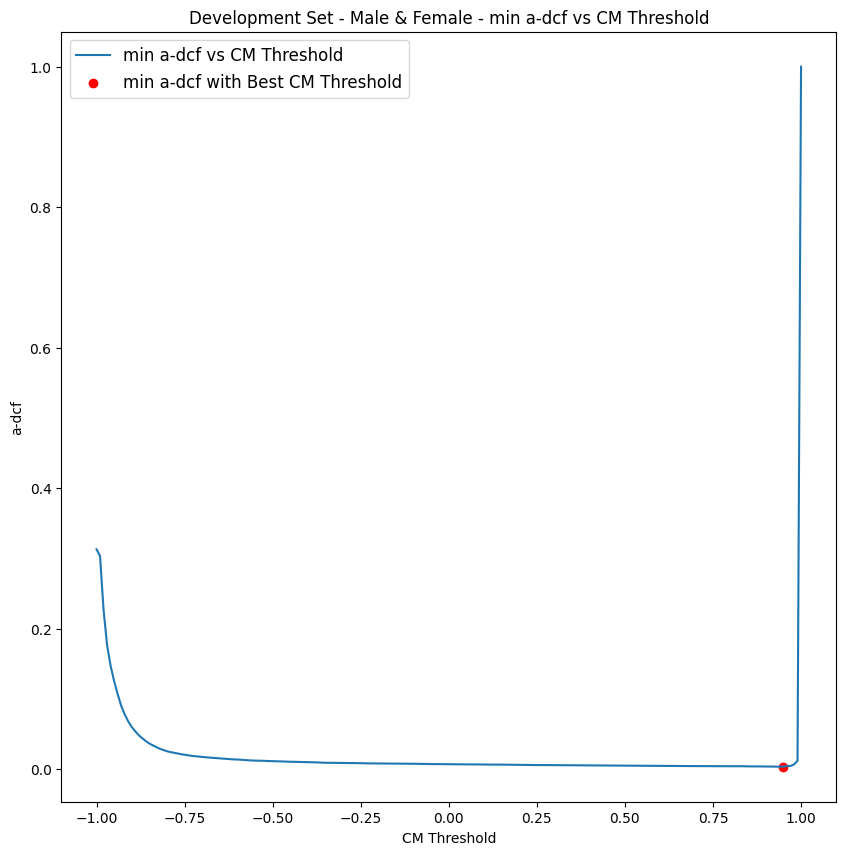

In [482]:
cm_filesname = Dev_dataset_all.name
cm_scores = -1*score_dev_without_gender.flatten()
asv_scores = results_dev_without_gender["asv_score"].values
asv_speakers =  results_dev_without_gender["speaker_id"].values
asv_filenames = results_dev_without_gender["file_name"].values
asv_labels = results_dev_without_gender["asv_label"].values
title = "Development Set - Male & Female - min a-dcf vs CM Threshold"
adjusted_scores_dev_without_gender, adjusted_labels_dev_without_gender, adjusted_speakers_dev_without_gender, adjusted_filename_dev_without_gender, global_min_a_dcf_dev_without_gender, global_min_a_dcf_thresh_dev_without_gender,all_a_dcf,all_a_dcf_thresh = compute_a_dcf(cm_filesname, cm_scores, asv_speakers,asv_scores,asv_labels, asv_filenames,title = title,gender= 'female')

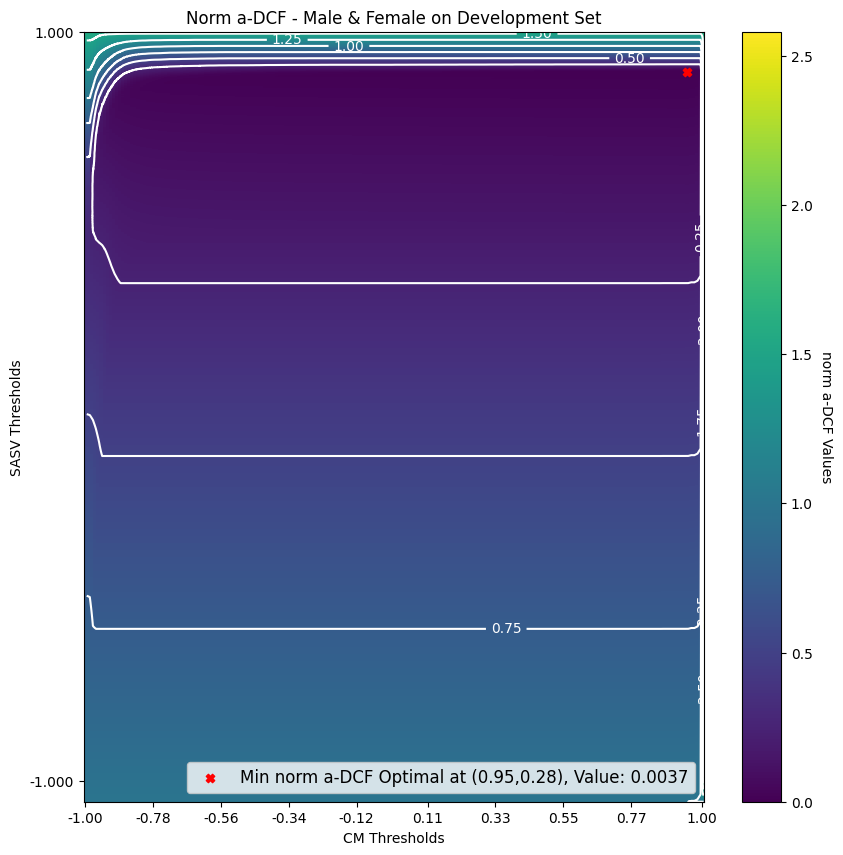

In [483]:
min_index = np.unravel_index(np.nanargmin(all_a_dcf), all_a_dcf.shape)
point_x_index = min_index[0]
point_y_index = min_index[1]

heatmap_norm_adcf(list_aDCF_norm = np.array(all_a_dcf),cm_thresholds = np.array(np.arange(0, 1.01, 0.01).tolist()),sasv_thresholds = all_a_dcf_thresh,target_values =  [0,0.5,1],title ="Norm a-DCF - Male & Female on Development Set",point_x_index= point_x_index, point_y_index= point_y_index,point_x_constrained=None,point_y_constrained=None,value = None,defualt_show = 'female')

## Eval:

In [484]:
from sklearn.metrics.pairwise import cosine_similarity
import torchaudio
import tqdm
from ASV_utils.config_thr import pmf_both_thr_spoof_test_all

txt_file_path = "output.txt"
csv_file_path = "output.csv"
enrollment_all  = enrollment_eval_male + enrollment_eval_female
list_files = file_name_according_speaker_id_eval
data_set = Eval_dataset_all
asv_model = classifier
spoof_labels = spoof_label_eval
list_speaker_id = speaker_id_list_eval
list_asv_label = asv_label_eval

#results_eval_without_gender = inference_system_cm_asv_avg_score_without_gender(spoof_labels,list_speaker_id,list_asv_label,txt_file_path,csv_file_path,pmf_both_thr_spoof_test_all,enrollment_all, list_files, data_set, spoof_model, asv_model, device, verbose = False, verbose_txt = False,verbose_csv = False)

In [485]:

import pickle
file_path = "./dcf_and_tdcf\dcf_avg_score/pmf_both_tdcf/asv_protocol/results_eval_without_gender_avg_score_both_asv_protocol.pkl"
with open(file_path, 'rb') as file:
    results_eval_without_gender = pickle.load(file)


In [486]:
labels_eval_without_gender = torch.Tensor(Eval_dataset_all.is_spoofed.values).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data_without_separation).cpu().numpy().copy()
with torch.no_grad():
    spoof_model = spoof_model.to(device)
    output = spoof_model(torch.Tensor(total_data).to(device))
    _ , score_eval_without_gender = spoof_model.loss(torch.Tensor(output).to(device),None)
    score_eval_without_gender = -1*score_eval_without_gender
    
score_eval_without_gender = score_eval_without_gender.cpu().numpy().copy()

eer_eval_without_gender, _ = my_functions.compute_eer(labels_eval_without_gender,score_eval_without_gender) # compute equal error rate


print(f"\tTest EER: ({100*eer_eval_without_gender}%)")

	Test EER: (10.273629504398746%)


In [487]:
def read_text_file(file_path):
    try:
        with open(file_path, 'r',) as file:
            lines = file.readlines()
            split_lines = [line.strip().split(' ')[0] for line in lines]
        return split_lines
    except FileNotFoundError:
        print("Error: File not found.")
        return None
    except Exception as e:
        print(f"Error: {e}")
        return None


file_path = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.male.trn.txt"
possible_speakers_male = read_text_file(file_path)

file_path = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.female.trn.txt"
possible_speakers_female = read_text_file(file_path)

In [488]:
from ASV_utils.tdcf_functions import compute_t_dcf
gender = 'male'

check_male =(results_eval_without_gender['speaker_id'].isin(possible_speakers_male))


bonafide_score_cm = score_eval_without_gender[(labels_eval_without_gender == 0) & (Eval_dataset_all.sex == gender)]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_eval_without_gender[(labels_eval_without_gender == 1) & (Eval_dataset_all.sex == gender)]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

target_scores = results_eval_without_gender.loc[(results_eval_without_gender['asv_label'] == "target") & check_male]["asv_score"].values
nontarget_scores = results_eval_without_gender.loc[(results_eval_without_gender['asv_label'] == "nontarget")  & check_male]["asv_score"].values
spoof_scores = results_eval_without_gender.loc[(results_eval_without_gender['asv_label'] ==  "spoof")  & check_male]["asv_score"].values

list_asv_score = [0.384]
type = 'constrained'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,target_scores,nontarget_scores,spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=2283, Nspoof=19656] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.83051 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.384
the CM thresholds is:  [-0.99463303 -0.99363303 -0.99356067 ...  0.99961174  0.99961245
  0.99963754]
the CM threshold min is: 0.9834378957748413
the tDCF_norm i

In [489]:
gender = 'female'
check_female =(results_eval_without_gender['speaker_id'].isin(possible_speakers_female))



bonafide_score_cm = score_eval_without_gender[(labels_eval_without_gender == 0) &  (Eval_dataset_all.sex == gender)]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_eval_without_gender[(labels_eval_without_gender == 1) &  (Eval_dataset_all.sex == gender)]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

target_scores = results_eval_without_gender.loc[(results_eval_without_gender['asv_label'] == "target") & check_female]["asv_score"].values
nontarget_scores = results_eval_without_gender.loc[(results_eval_without_gender['asv_label'] == "nontarget")  & check_female]["asv_score"].values
spoof_scores = results_eval_without_gender.loc[(results_eval_without_gender['asv_label'] ==  "spoof")  & check_female]["asv_score"].values

list_asv_score = [0.384]
type = 'constrained'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,target_scores,nontarget_scores,spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=5072, Nspoof=44226] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.90121 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.384
the CM thresholds is:  [-0.99510361 -0.99410361 -0.99379742 ...  0.99964315  0.99964869
  0.99966168]
the CM threshold min is: 0.991218090057373
the tDCF_norm is

In [490]:
from ASV_utils.tdcf_functions import compute_t_dcf
gender = 'all'
bonafide_score_cm = score_eval_without_gender[labels_eval_without_gender == 0]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_eval_without_gender[labels_eval_without_gender == 1]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

target_scores = results_eval_without_gender.loc[results_eval_without_gender['asv_label'] == "target"]["asv_score"].values
nontarget_scores = results_eval_without_gender.loc[results_eval_without_gender['asv_label'] == "nontarget"]["asv_score"].values
spoof_scores = results_eval_without_gender.loc[results_eval_without_gender['asv_label'] ==  "spoof"]["asv_score"].values

list_asv_score = [0.375,0.384]
type = 'constrained'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,target_scores,nontarget_scores,spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=7355, Nspoof=63882] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.83829 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.375
the CM thresholds is:  [-0.99510361 -0.99410361 -0.99379742 ...  0.99964315  0.99964869
  0.99966168]
the CM threshold min is: 0.9912126064300537
the tDCF_norm i

In [491]:
results_eval_without_gender

,file_name,its_spoof,spoof_score,spoof_ground_truth,asv_score,speaker_id,find_speaker_in_enroll,asv_label,attack_type,in_cm_protocol
0,LA_E_1103494,False,-0.998118,False,0.607649,LA_0015,True,target,none,True
1,LA_E_4861467,False,-0.998306,False,0.652226,LA_0015,True,target,none,True
2,LA_E_6229989,False,-0.998424,False,0.645379,LA_0015,True,target,none,True
3,LA_E_4483232,False,-0.998880,False,0.710620,LA_0015,True,target,none,True
4,LA_E_3110493,False,-0.999037,False,0.564846,LA_0015,True,target,none,True
...,...,...,...,...,...,...,...,...,...,...
102574,LA_E_6346294,False,-0.996954,True,0.276046,LA_0020,True,spoof,A18,True
102575,LA_E_4892925,True,0.978704,True,0.260937,LA_0020,True,spoof,A19,True
102576,LA_E_4102704,False,-0.996466,True,0.218130,LA_0020,True,spoof,A17,True
102577,LA_E_4796101,True,-0.966712,True,0.287498,LA_0020,True,spoof,A18,True


a-DCF: 0.49932, threshold: 0.48416
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.49849, threshold: 0.48416
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48185, threshold: 0.48416
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.46142, threshold: 0.48416
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.43988, threshold: 0.48416
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.41742, threshold: 0.48416
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.39568, threshold: 0.45480
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.37758, threshold: 0.44558
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.36416, threshold: 0.44558
CostModel(Pspf=0.05, Pnontrg=

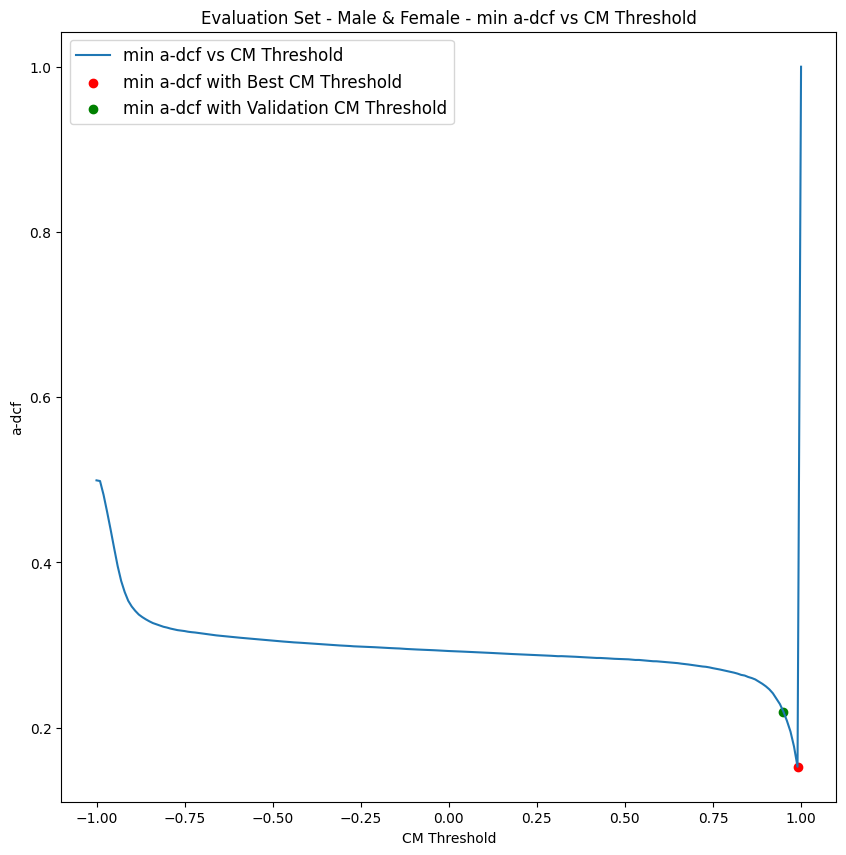

In [492]:
cm_filesname = Eval_dataset_all.name
cm_scores = -1*score_eval_without_gender.flatten()
asv_scores = results_eval_without_gender["asv_score"].values
asv_speakers =  results_eval_without_gender["speaker_id"].values
asv_filenames = results_eval_without_gender["file_name"].values
asv_labels = results_eval_without_gender["asv_label"].values
title = "Evaluation Set - Male & Female - min a-dcf vs CM Threshold"
val_thr = 0.9500000000000017 
adjusted_scores_eval_without_gender, adjusted_labels_eval_without_gender, adjusted_speakers_eval_without_gender, adjusted_filename_eval_without_gender, global_min_a_dcf_eval_without_gender, global_min_a_dcf_thresh_eval_without_gender,all_a_dcf,all_a_dcf_thresh = compute_a_dcf(cm_filesname, cm_scores, asv_speakers,asv_scores,asv_labels, asv_filenames,title = title, val_CM_threshold = val_thr,gender= 'female')

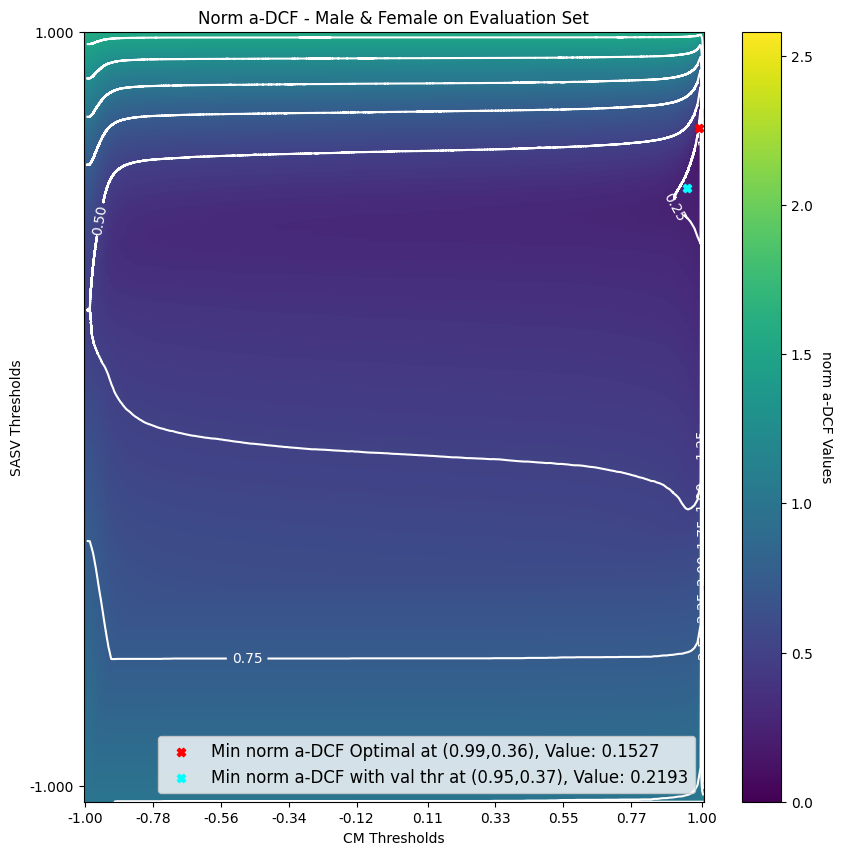

In [493]:
min_index = np.unravel_index(np.nanargmin(all_a_dcf), all_a_dcf.shape)
point_x_index = min_index[0]
point_y_index = min_index[1]
cm_thresholds = np.array(np.arange(-1, 1.01, 0.01).tolist())
point_x_constrained = np.where(cm_thresholds == val_thr)[0][0]
point_y_constrained = np.nanargmin(np.array(all_a_dcf)[point_x_constrained])
heatmap_norm_adcf(list_aDCF_norm = np.array(all_a_dcf),cm_thresholds = cm_thresholds,sasv_thresholds = all_a_dcf_thresh,target_values =  [0,0.5,1],title ="Norm a-DCF - Male & Female on Evaluation Set",point_x_index= point_x_index, point_y_index= point_y_index,point_x_constrained=point_x_constrained,point_y_constrained=point_y_constrained,value = None,defualt_show = 'female')

### read from ASVspoof2019 scores:

In [494]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import utils.eval_metrics as eval_metrics 
def read_txt_ASV2019_scores(file_path):
    is_spoofed = []
    label = []
    score = []
    with open(file_path, 'r') as file:
        for line in file:
            parts = line.strip().split(' ')
            if len(parts) != 3:
                raise Exception("The line in the file is not in the right format")
            is_spoofed.append(parts[0])
            label.append(parts[1])
            score.append(parts[2])
            
    return pd.Series(is_spoofed), pd.Series(label), pd.Series(score)

### Dev

In [495]:

file_path ="./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.gi.trl.scores.txt"
 
ASV2019_attack_type ,ASV2019_label,ASV2019_scores  = read_txt_ASV2019_scores(file_path)

bonafide_score_cm = score_dev_without_gender[labels_dev_without_gender == 0]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_dev_without_gender[labels_dev_without_gender == 1]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

ASV2019_target_scores = ASV2019_scores.loc[ASV2019_label == "target"].astype(float)
ASV2019_nontarget_scores = ASV2019_scores.loc[ASV2019_label == "nontarget"].astype(float)
ASV2019_spoof_scores = ASV2019_scores.loc[ASV2019_label == "spoof"].astype(float)

ASV2019_eer_scores_dev,ASV2019_thr_eer_scores_dev,_,_ = eval_metrics.compute_eer(ASV2019_target_scores.values.astype(float),ASV2019_nontarget_scores.values.astype(float))

list_asv_score = [ASV2019_thr_eer_scores_dev]
type = 'constrained'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,ASV2019_target_scores,ASV2019_nontarget_scores,ASV2019_spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=2548, Nspoof=22296] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.40799 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  -3.548998
the CM thresholds is:  [-0.9967884  -0.9957884  -0.99551475 ...  0.99963063  0.99965298
  0.99969369]
the CM threshold min is: 0.8544267416000366
the tDCF_no

a-DCF: 0.60009, threshold: 6.83363
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.57914, threshold: 6.83363
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.45239, threshold: 5.98618
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.36900, threshold: 4.11664
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.31182, threshold: 0.31796
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.26193, threshold: -0.88591
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.21877, threshold: -0.88591
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.18204, threshold: -2.84202
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.15472, threshold: -2.84202
CostModel(Pspf=0.05, Pnon

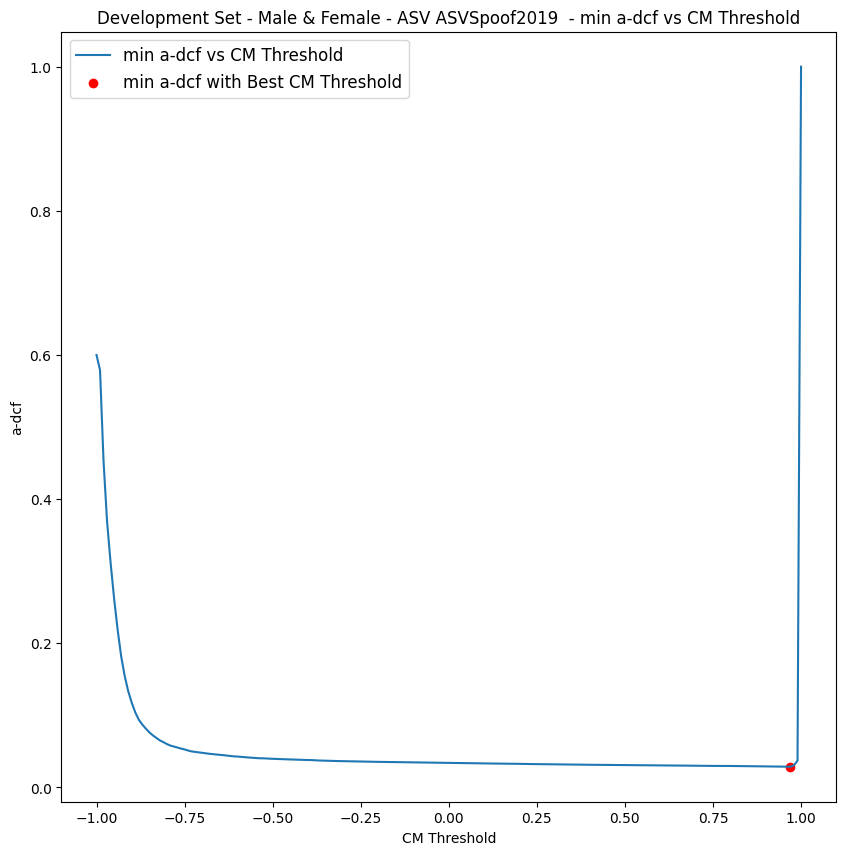

In [496]:
cm_filesname = Dev_dataset_all.name
cm_scores = -1*score_dev_without_gender.flatten()
asv_scores = ASV2019_scores
asv_speakers =  results_dev_without_gender["speaker_id"].values
asv_filenames = results_dev_without_gender["file_name"].values
asv_labels = ASV2019_label
title = "Development Set - Male & Female - ASV ASVSpoof2019  - min a-dcf vs CM Threshold"
adjusted_scores_dev_without_gender2, adjusted_labels_dev_without_gender, adjusted_speakers_dev_without_gender2, adjusted_filename_dev_without_gender2, global_min_a_dcf_dev_without_gender2, global_min_a_dcf_thresh_dev_without_gender2,all_a_dcf,all_a_dcf_thresh = compute_a_dcf(cm_filesname, cm_scores, asv_speakers,asv_scores,asv_labels, asv_filenames,title = title,gender= 'female')

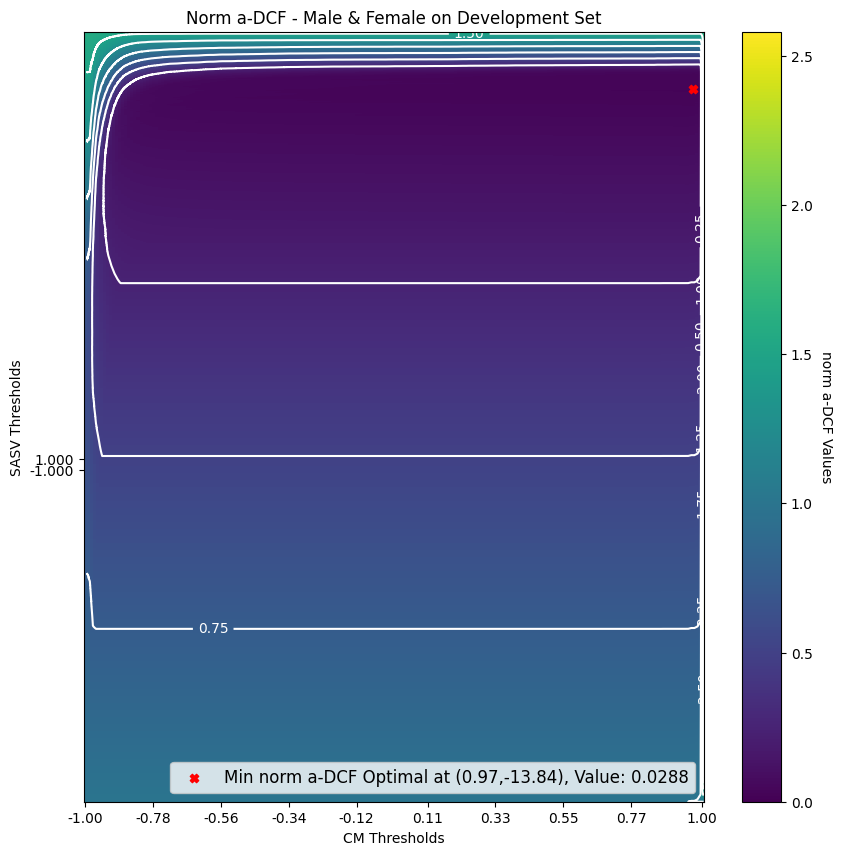

In [497]:
min_index = np.unravel_index(np.nanargmin(all_a_dcf), all_a_dcf.shape)
point_x_index = min_index[0]
point_y_index = min_index[1]

heatmap_norm_adcf(list_aDCF_norm = np.array(all_a_dcf),cm_thresholds = np.array(np.arange(-1, 1.01, 0.01).tolist()),sasv_thresholds = all_a_dcf_thresh,target_values =  [0,0.5,1],title ="Norm a-DCF - Male & Female on Development Set",point_x_index= point_x_index, point_y_index= point_y_index,point_x_constrained=None,point_y_constrained=None,value = None,defualt_show = 'female')

### Eval

In [498]:
file_path ="./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.gi.trl.scores.txt"
 
ASV2019_attack_type ,ASV2019_label,ASV2019_scores  = read_txt_ASV2019_scores(file_path)

bonafide_score_cm = score_eval_without_gender[labels_eval_without_gender == 0]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_eval_without_gender[labels_eval_without_gender == 1]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

ASV2019_target_scores = ASV2019_scores.loc[ASV2019_label == "target"].astype(float)
ASV2019_nontarget_scores = ASV2019_scores.loc[ASV2019_label == "nontarget"].astype(float)
ASV2019_spoof_scores = ASV2019_scores.loc[ASV2019_label == "spoof"].astype(float)

ASV2019_eer_scores_eval,ASV2019_thr_eer_scores_eval,_,_ = eval_metrics.compute_eer(ASV2019_target_scores.values.astype(float),ASV2019_nontarget_scores.values.astype(float))


list_asv_score = [ASV2019_thr_eer_scores_dev,ASV2019_thr_eer_scores_eval]
type = 'constrained'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,ASV2019_target_scores,ASV2019_nontarget_scores,ASV2019_spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=7355, Nspoof=63882] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.43442 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  -3.548998
the CM thresholds is:  [-0.99510361 -0.99410361 -0.99379742 ...  0.99964315  0.99964869
  0.99966168]
the CM threshold min is: 0.9925036430358887
the tDCF_no

a-DCF: 0.68344, threshold: -1.52404
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.68217, threshold: -1.52404
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.65758, threshold: -1.52404
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.62635, threshold: -1.52404
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.59327, threshold: -5.34931
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.55901, threshold: -5.34931
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.52809, threshold: -5.34931
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.50168, threshold: -5.34931
CostModel(Pspf=0.05, Pnontrg=0.0095, Ptrg=0.9405, Cmiss=1, Cfa_asv=10, Cfa_cm=10)
a-DCF: 0.48122, threshold: -6.76904
CostModel(Pspf=0.05,

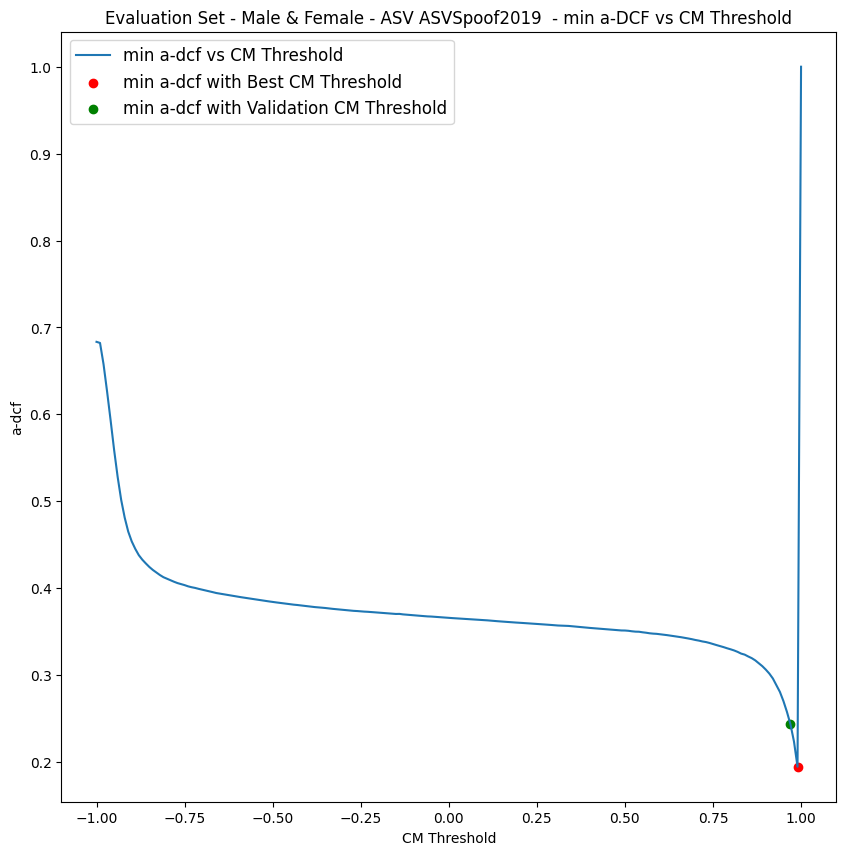

In [499]:
cm_filesname = Eval_dataset_all.name
cm_scores = -1*score_eval_without_gender.flatten()
asv_scores = ASV2019_scores
asv_speakers =  results_eval_without_gender["speaker_id"].values
asv_filenames = results_eval_without_gender["file_name"].values
asv_labels = ASV2019_label
title = "Evaluation Set - Male & Female - ASV ASVSpoof2019  - min a-DCF vs CM Threshold"
val_thr =  0.9700000000000017
adjusted_scores_eval_without_gender2, adjusted_labels_eval_without_gender2, adjusted_speakers_eval_without_gender2, adjusted_filename_eval_without_gender2, global_min_a_dcf_eval_without_gender2, global_min_a_dcf_thresh_eval_without_gender2,all_a_dcf,all_a_dcf_thresh = compute_a_dcf(cm_filesname, cm_scores, asv_speakers,asv_scores,asv_labels, asv_filenames,title = title, val_CM_threshold = val_thr,gender= 'female')

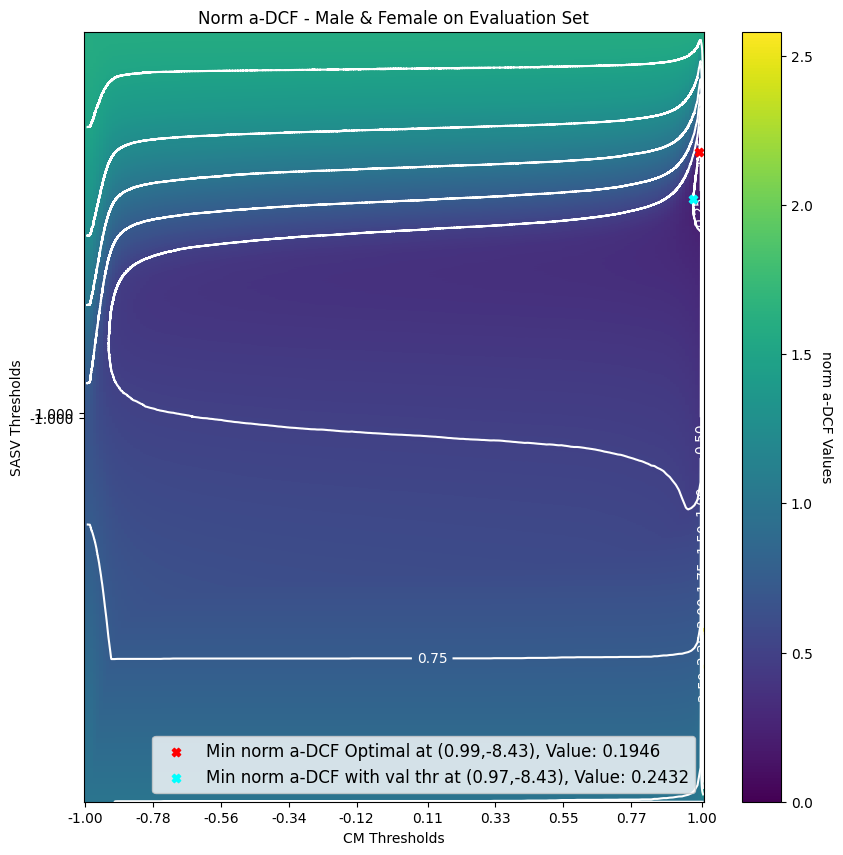

In [500]:
min_index = np.unravel_index(np.nanargmin(all_a_dcf), all_a_dcf.shape)
point_x_index = min_index[0]
point_y_index = min_index[1]
cm_thresholds = np.array(np.arange(-1, 1.01, 0.01).tolist())
point_x_constrained = np.where(cm_thresholds == val_thr)[0][0]
point_y_constrained = np.nanargmin(np.array(all_a_dcf)[point_x_constrained])
heatmap_norm_adcf(list_aDCF_norm = np.array(all_a_dcf),cm_thresholds = cm_thresholds,sasv_thresholds = all_a_dcf_thresh,target_values =  [0,0.5,1],title ="Norm a-DCF - Male & Female on Evaluation Set",point_x_index= point_x_index, point_y_index= point_y_index,point_x_constrained=point_x_constrained,point_y_constrained=point_y_constrained,value = None,defualt_show = 'female')